## Array Rearrangement Dataset Acquisition

Import libraries

In [1]:
from pytweezer.experiment.motmaster_client import MotMasterClient
from pytweezer.drivers.imagemX2 import ImagEMX2Camera
from pytweezer.drivers.slm import SLM
from pytweezer.drivers.thorcam import ThorCamera
from pytweezer.experiment.experiment_parameter_manager import ExpParameterManager
import pytweezer.phasemask as pm
import pytweezer.analysis as an
import numpy as np
import matplotlib.pyplot as plt

ExpParams = ExpParameterManager()

Initialise and configure devices

In [2]:
exp : MotMasterClient = MotMasterClient()
motcam : ThorCamera = ThorCamera(id="motcam")
slm : SLM = SLM()
hamcam : ImagEMX2Camera = ImagEMX2Camera()

Rb MotMasterClient initialised.
Thorlabs TLCamera - motcam - initialised.
SLM 1 initialised: 1024x1024 @ 8-bit, serial 7752, 40.200 degC
SLM 1 loaded LUT "C:\Program Files\Meadowlark Optics\Blink Plus\LUT Files\slm40_at852.LUT"
ImagEM X2 camera initialised.


In [5]:
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)
exp.set_motmaster_experiment("RbTweezerBasic2026_2")

motcam.set_trigger_source("bulb")

hamcam.set_trigger_source("ext")
hamcam.set_external_exposure_mode()
hamcam.enable_em_gain(True)
hamcam.enable_direct_em_gain(True)
hamcam.set_sensitivity(600)
hamcam.timeout = 60*20
X0, Y0, WIDTH, HEIGHT = 110, 220, 256, 256
hamcam.set_roi(X0, WIDTH, Y0, HEIGHT)

## Generate Initial and Final Array Hologram

In [6]:
dx, dy = 8.0, 12.0
PM = pm.OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=17.3,
                 slm_pitch_um=17,
                 slm_res=(1024,1024),
                 input_beam_waist_mm=16,
                 fresnel_f_mm=1072,
                 blaze_dx_dy_um=(40+dx, -8+dy),
                 zernike_coeff_dict={5:1.195, 6:0.725, 7:0.970, 8:0.478, 9:-1.091, 10:0.303, 11:0.021, 12:0.072, 13:0.049})

gauss2d = lambda x, y, A, x0, y0, sx, sy, offset: (A * np.exp(-(((x - x0) ** 2) / (2 * sx ** 2) + ((y - y0) ** 2) / (2 * sy ** 2)))) + offset
A, x0, y0, sx, sy, offset = [-2.14197604e+03, -1.11443850e+01 - dx, 2.09919600e+00 - dy, 2.95002910e+03, 2.64281503e+03, 2.14239505e+03]

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (48.0, 4.0) um


Initial array

In [7]:
W1 = np.ones((10,10))
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W1, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = (W1 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape), A, x0, y0, sx, sy, offset)).flatten()

terms1 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array1, terms1, _ = PM.superposition_optimization(terms1, max_iter=2000, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 10x10
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 1.78e-05 | Uniformity: 47.58% | Min/Max ratio: 0.087
Iteration 010 | Mean-Squared Error: 2.29e-07 | Uniformity: 84.05% | Min/Max ratio: 0.526
Iteration 020 | Mean-Squared Error: 2.88e-08 | Uniformity: 83.17% | Min/Max ratio: 0.529
Iteration 030 | Mean-Squared Error: 9.07e-09 | Uniformity: 83.30% | Min/Max ratio: 0.526
Iteration 040 | Mean-Squared Error: 4.81e-09 | Uniformity: 83.32% | Min/Max ratio: 0.521
Iteration 050 | Mean-Squared Error: 1.50e-09 | Uniformity: 83.46% | Min/Max ratio: 0.525
Iteration 060 | Mean-Squared Error: 1.20e-09 | Uniformity: 83.52% | Min/Max ratio: 0.525
Iteration 070 | Mean-Squared Error: 2.15e-09 | Uniformity: 83.57% | Min/Max ratio: 0.524
Iteration 080 | Mean-Squared Error: 3.19e-09 | Uniformity: 83.67% | Min/Max ratio: 0.523
Iteration 090 | Mean-Squared Error: 2.37e-09 | Uniformity: 83.67% | Min/Max ratio: 0.525
Itera

Final array

In [8]:
W2 = np.ones((7,7))
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W2, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = (W2 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape), A, x0, y0, sx, sy, offset)).flatten()

terms2 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array2, terms2, _ = PM.superposition_optimization(terms2, max_iter=5000, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 7x7
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 6.53e-05 | Uniformity: 53.84% | Min/Max ratio: 0.093
Iteration 010 | Mean-Squared Error: 7.63e-07 | Uniformity: 87.46% | Min/Max ratio: 0.615
Iteration 020 | Mean-Squared Error: 1.79e-07 | Uniformity: 87.79% | Min/Max ratio: 0.624
Iteration 030 | Mean-Squared Error: 5.87e-08 | Uniformity: 88.16% | Min/Max ratio: 0.631
Iteration 040 | Mean-Squared Error: 4.37e-08 | Uniformity: 88.67% | Min/Max ratio: 0.627
Iteration 050 | Mean-Squared Error: 1.01e-08 | Uniformity: 88.61% | Min/Max ratio: 0.646
Iteration 060 | Mean-Squared Error: 5.17e-09 | Uniformity: 88.58% | Min/Max ratio: 0.649
Iteration 070 | Mean-Squared Error: 4.43e-09 | Uniformity: 88.58% | Min/Max ratio: 0.648
Iteration 080 | Mean-Squared Error: 4.80e-09 | Uniformity: 88.56% | Min/Max ratio: 0.648
Iteration 090 | Mean-Squared Error: 3.82e-09 | Uniformity: 88.52% | Min/Max ratio: 0.647
Iterati

Load initial array onto the SLM

In [9]:
pm_composite = PM.superimpose([pm_array1, PM.fresnel, PM.blaze, PM.zernike])
pm_composite_uint8 = PM.transform_phase_8bit(pm_composite).get()
slm.update_mask(pm_composite_uint8)

## Baseline - Load and Image Initial Array

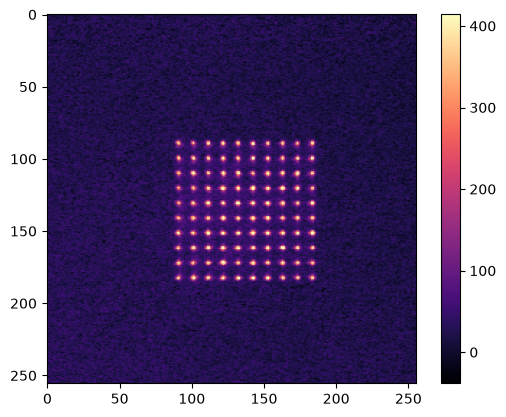

In [10]:
# Experiment and camera setup
n_iterations = 100
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)
hamcam.start_acquisition()
exp.start_motmaster_experiment({
    "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"),
    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"),
    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
    "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"),
    "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
    "BackgroundDrop": 1})

imgs = hamcam.acquire_n_frames(n_iterations * 2)
imgs1, imgs2 = imgs[::2], imgs[1::2]
img_average = an.tweezer_show_bg_subtracted(imgs1, imgs2, cmap='magma', show=True, vmaxfactor=0.6, show_grid=True)

Looking for trap sites...
10x10 array detected.


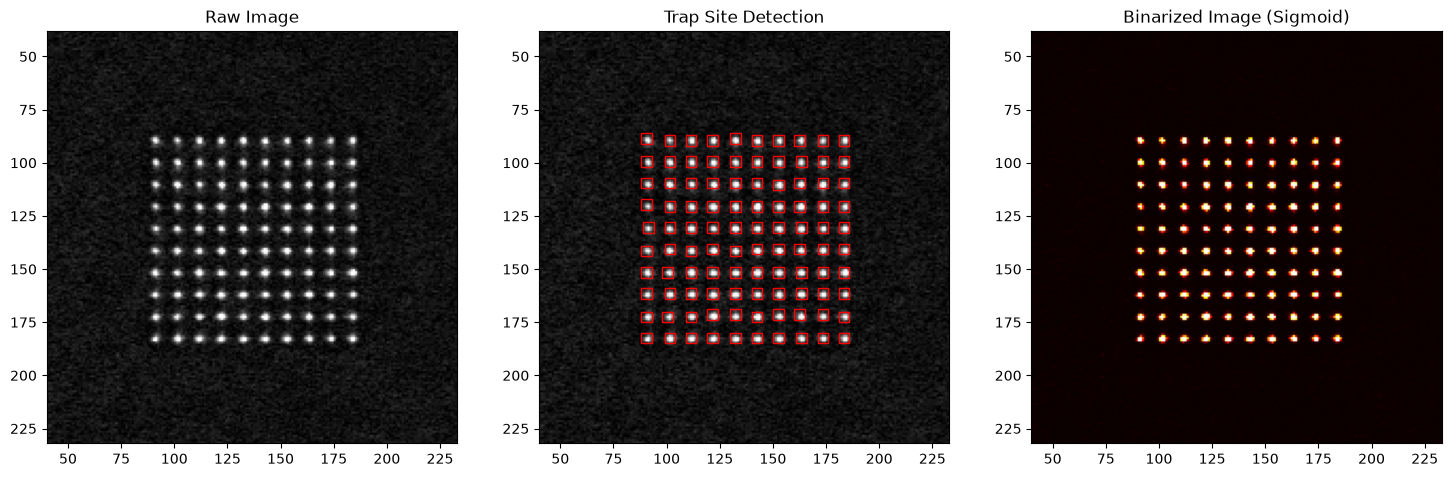

Trap (0, 0) Loading Probability : 58.00 %
Trap (0, 1) Loading Probability : 45.00 %
Trap (0, 2) Loading Probability : 51.00 %
Trap (0, 3) Loading Probability : 60.00 %
Trap (0, 4) Loading Probability : 59.00 %
Trap (0, 5) Loading Probability : 51.00 %
Trap (0, 6) Loading Probability : 59.00 %
Trap (0, 7) Loading Probability : 54.00 %
Trap (0, 8) Loading Probability : 50.00 %
Trap (0, 9) Loading Probability : 60.00 %
Trap (1, 0) Loading Probability : 54.00 %
Trap (1, 1) Loading Probability : 57.00 %
Trap (1, 2) Loading Probability : 56.00 %
Trap (1, 3) Loading Probability : 51.00 %
Trap (1, 4) Loading Probability : 50.00 %
Trap (1, 5) Loading Probability : 52.00 %
Trap (1, 6) Loading Probability : 55.00 %
Trap (1, 7) Loading Probability : 55.00 %
Trap (1, 8) Loading Probability : 56.00 %
Trap (1, 9) Loading Probability : 56.00 %
Trap (2, 0) Loading Probability : 48.00 %
Trap (2, 1) Loading Probability : 64.00 %
Trap (2, 2) Loading Probability : 46.00 %
Trap (2, 3) Loading Probability : 

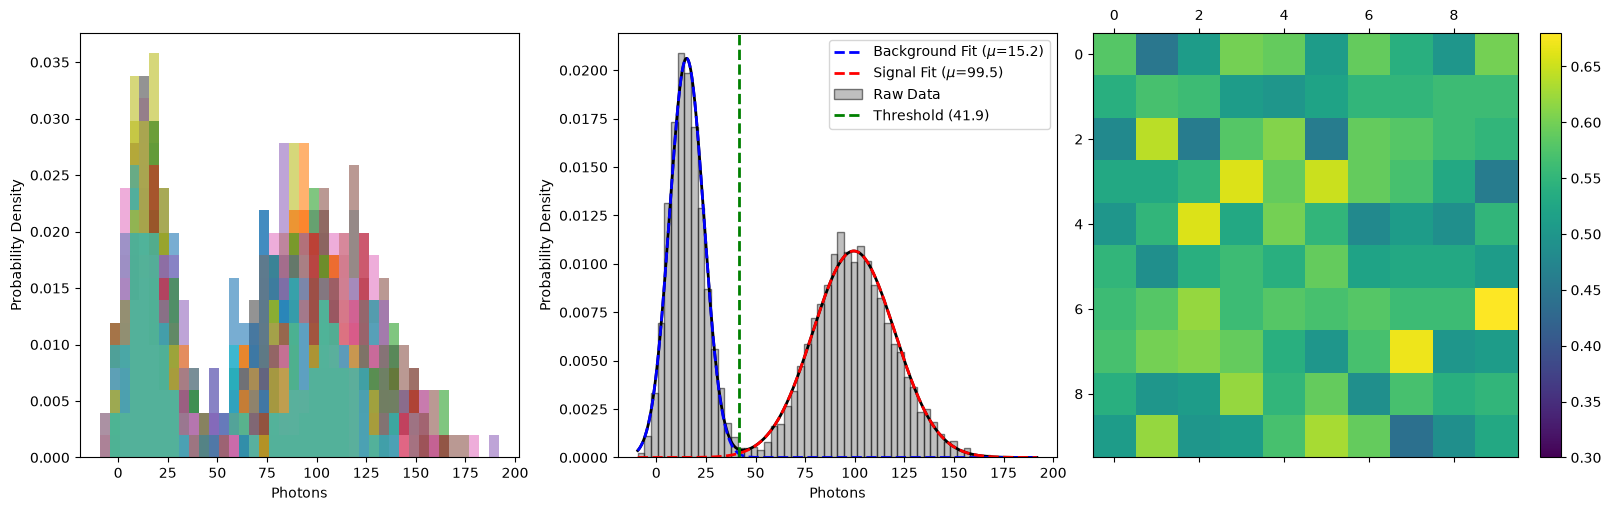

In [11]:
array_shape_1 = [10, 10]
window = 5
feature_size = 10

filtered_img_average = an.morphological_tophat_high_pass(img_average, feature_size=feature_size)
grid_positions_1, detection_threshold = an.detect_trap_sites(filtered_img_average, array_shape_1, detection_step=200)
imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
an.visualize_results(filtered_img_average, grid_positions_1, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)
photons, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(imgs_filtered_1, grid_positions_1, array_shape_1, threshold_detection=True, binning=60)

Trap (0, 0) Loading Probability : 58.00 %
Trap (0, 1) Loading Probability : 45.00 %
Trap (0, 2) Loading Probability : 51.00 %
Trap (0, 3) Loading Probability : 60.00 %
Trap (0, 4) Loading Probability : 59.00 %
Trap (0, 5) Loading Probability : 51.00 %
Trap (0, 6) Loading Probability : 59.00 %
Trap (0, 7) Loading Probability : 54.00 %
Trap (0, 8) Loading Probability : 50.00 %
Trap (0, 9) Loading Probability : 60.00 %
Trap (1, 0) Loading Probability : 55.00 %
Trap (1, 1) Loading Probability : 57.00 %
Trap (1, 2) Loading Probability : 55.00 %
Trap (1, 3) Loading Probability : 51.00 %
Trap (1, 4) Loading Probability : 50.00 %
Trap (1, 5) Loading Probability : 52.00 %
Trap (1, 6) Loading Probability : 55.00 %
Trap (1, 7) Loading Probability : 56.00 %
Trap (1, 8) Loading Probability : 57.00 %
Trap (1, 9) Loading Probability : 56.00 %
Trap (2, 0) Loading Probability : 48.00 %
Trap (2, 1) Loading Probability : 63.00 %
Trap (2, 2) Loading Probability : 46.00 %
Trap (2, 3) Loading Probability : 

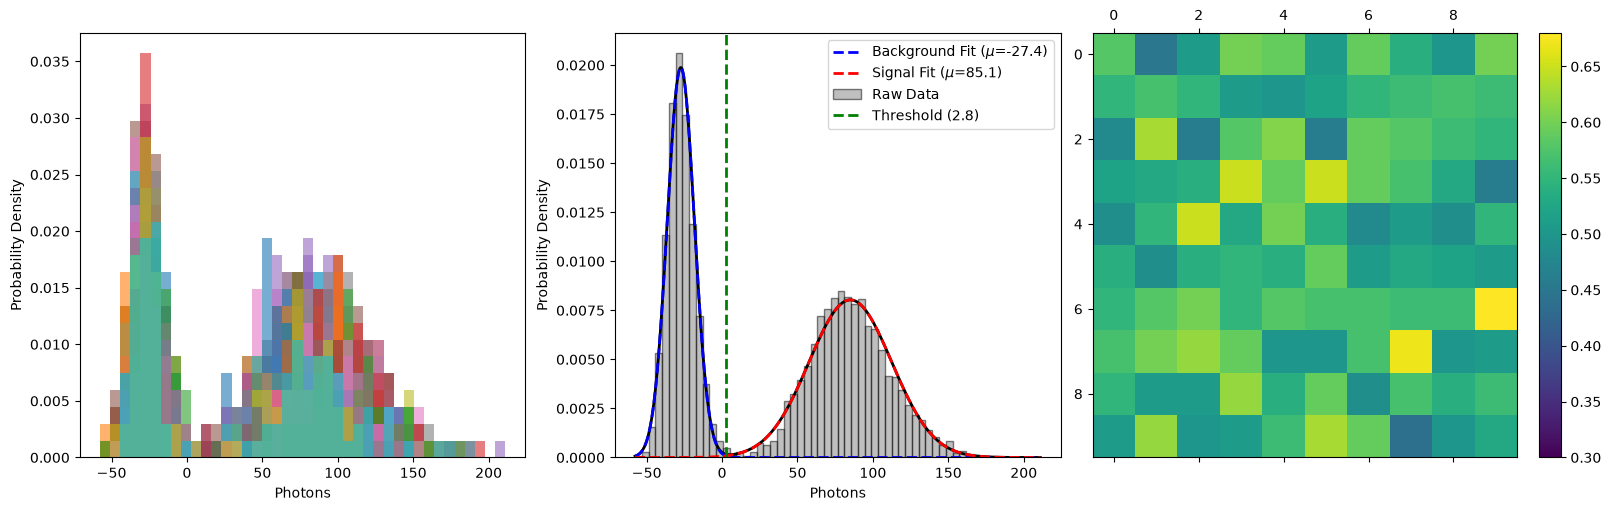

In [12]:
psf_window = 9

# Templates come from the raw frames - the matched filter needs no top-hat.
scorer = an.SiteScorer.from_images(imgs1, grid_positions_1, array_shape_1, window_size=psf_window)
photons, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(
    imgs1, grid_positions_1, array_shape_1, scorer=scorer, threshold_detection=True, binning=60)

scorer.threshold = threshold_1 * 1.0
print(f"PSF threshold {scorer.threshold:.2f} photons, detection fidelity {fidelity*100:.3f} %")

## Routine MOT Shim Coil Optimisation

In [39]:
from skopt.space import Real, Integer
from skopt.utils import use_named_args
from skopt import Optimizer

In [40]:
# --- 1. Define the Experimental Search Space ---
dimensions = [  
    Real(name='tMOTShimXccValue', low=0.0, high=0.5),
    Real(name='tMOTShimYccValue', low=-5.0, high=0.0),
    Real(name='tMOTShimZccValue', low=-1.0, high=0.0)
]

# Experiment and camera setup
n_iterations = 20
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)

@use_named_args(dimensions=dimensions)
def tweezer_exp_objective(tMOTShimXccValue, tMOTShimYccValue, tMOTShimZccValue):
    hamcam.start_acquisition()
    exp.start_motmaster_experiment({
            "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
            "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
            "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
            "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
            "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
            "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
            "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
            "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
            "tMOTShimXccValue": tMOTShimXccValue, "tMOTShimYccValue": tMOTShimYccValue, "tMOTShimZccValue": tMOTShimZccValue,
            "tMOTLoadingDuration": 20000, "PatternLength": 40000})

    imgs = hamcam.acquire_n_frames(n_iterations * 2)
    imgs1, imgs2 = imgs[::2], imgs[1::2]
    imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]

    _, loading_probabilities, _, _ = an.get_array_loading_statistics(imgs_filtered_1, grid_positions_1, array_shape_1, threshold_detection=False, threshold=threshold_1, binning=60, show_histogram=False, verbose=False)    
    mean_loading_probability = np.mean(loading_probabilities)
    measured_loss = 1.0 - mean_loading_probability

    print(f"Parameters: tMOTShimXccValue = {tMOTShimXccValue:.2f}, tMOTShimYccValue = {tMOTShimYccValue:.2f}, tMOTShimZccValue = {tMOTShimZccValue:.2f}  |  Mean Loading Probability = {mean_loading_probability:.4f}")
    return measured_loss

In [41]:
print("Starting Bayesian Optimization with dynamic exploration...")

n_calls = 30
n_initial_points = 5
xi_start = 0.100
xi_end = 0.001

opt = Optimizer(
    dimensions=dimensions,
    n_initial_points=n_initial_points,
    acq_func='EI',
    random_state=50
)

# Custom optimization loop
for i in range(n_calls):
    current_xi = xi_start - (xi_start - xi_end) * (i / (n_calls - 1))
    opt.acq_func_kwargs = {'xi': current_xi}
    suggested_params = opt.ask()
    loss = tweezer_exp_objective(suggested_params)
    result = opt.tell(suggested_params, loss)
    print(f"Iteration {i+1}/{n_calls} (xi = {current_xi:.4f})")
    print(f"  Current score: {(1-loss):.4f}")
    print(f"  Best score: {(1-result.fun):.4f}\n")

# --- 4. Analyze the Results ---
print("\n" + "="*40)
print("Optimization Complete!")
print("="*40)

high_score = 1 - result.fun
best_params = result.x

print(f"Best Parameters Found:")
for dim, value in zip(dimensions, best_params):
    print(f"  {dim.name}: {value:.4f}")

Starting Bayesian Optimization with dynamic exploration...
Parameters: tMOTShimXccValue = 0.06, tMOTShimYccValue = -4.63, tMOTShimZccValue = -0.39  |  Mean Loading Probability = 0.1595
Iteration 1/30 (xi = 0.1000)
  Current score: 0.1595
  Best score: 0.1595

Parameters: tMOTShimXccValue = 0.01, tMOTShimYccValue = -4.24, tMOTShimZccValue = -0.05  |  Mean Loading Probability = 0.0175
Iteration 2/30 (xi = 0.0966)
  Current score: 0.0175
  Best score: 0.1595

Parameters: tMOTShimXccValue = 0.40, tMOTShimYccValue = -3.78, tMOTShimZccValue = -0.67  |  Mean Loading Probability = 0.3375
Iteration 3/30 (xi = 0.0932)
  Current score: 0.3375
  Best score: 0.3375

Parameters: tMOTShimXccValue = 0.22, tMOTShimYccValue = -4.33, tMOTShimZccValue = -0.41  |  Mean Loading Probability = 0.1640
Iteration 4/30 (xi = 0.0898)
  Current score: 0.1640
  Best score: 0.3375

Parameters: tMOTShimXccValue = 0.49, tMOTShimYccValue = -4.56, tMOTShimZccValue = -0.71  |  Mean Loading Probability = 0.2430
Iteration 5

In [42]:
ExpParams.set_parameter("tMOTShimXccValue", best_params[0])
ExpParams.set_parameter("tMOTShimYccValue", best_params[1])
ExpParams.set_parameter("tMOTShimZccValue", best_params[2])
ExpParams.save_parameters()

Parameter 'tMOTShimXccValue' set to 0.006588371729773725.
Parameter 'tMOTShimYccValue' set to -0.7453203798454666.
Parameter 'tMOTShimZccValue' set to -0.6796948826571556.
Parameters saved.


## Baseline Survival Probabilities

In [367]:
# Experiment and camera setup
n_iterations = 400
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)
hamcam.start_acquisition()
exp.start_motmaster_experiment({
    "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"),
    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"),
    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
    "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"),
    "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
    "BackgroundDrop": 0})

imgs = hamcam.acquire_n_frames(n_iterations * 2)
imgs1, imgs2 = imgs[::2], imgs[1::2]

imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
imgs_filtered_2 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs2]
photons_1, _, _, fidelity = an.get_array_loading_statistics(imgs_filtered_1, grid_positions_1, array_shape_1, threshold_detection=True, binning=60, show_histogram=False, verbose=False)
photons_2, _, _, fidelity = an.get_array_loading_statistics(imgs_filtered_2, grid_positions_1, array_shape_1, threshold_detection=True, binning=60, show_histogram=False, verbose=False)
baseline_survival_probability = an.extract_survival_probability(imgs_filtered_1, imgs_filtered_2, grid_positions_1, array_shape_1, window_size=window)
print(f"Baseline survival probability: {baseline_survival_probability:.4f}")

Baseline survival probability: 0.9717


#### Save Data

In [81]:
import os
import pickle

data_dir = "C:\\Users\\tweez\\Box\\Working folder\\caftweezers\\Data\\12Aug26"
dataset_title = "imaging_survival_40ms"

os.makedirs(os.path.join(data_dir, dataset_title), exist_ok=True)

# Save imgs1 and imgs2 to two pickle files, one called initial, one called final, and one called photon_data
with open(os.path.join(data_dir, dataset_title, "initial_imgs.pkl"), "wb") as f:
    pickle.dump(imgs1, f)
with open(os.path.join(data_dir, dataset_title, "final_imgs.pkl"), "wb") as f:
    pickle.dump(imgs2, f)


## Rearrangement Exp 1

In [66]:
import asyncio
from pytweezer.coordinators.rearrangement import Rearrangement
import time

coordinator = Rearrangement({"camera": hamcam, "slm": slm, "phasemask_generator": PM}, {})

data1, array_shape1 = np.stack(terms1[:4]), terms1[4]
data2, array_shape2 = np.stack(terms2[:4]), terms2[4]
await asyncio.to_thread(
    coordinator.initialise,
    data1, data2, array_shape1, array_shape2,
    d0=0.5, fps=1/(1e-6), threshold=an.convert_photons_to_counts(threshold_1)*1.1,
    grid_positions=grid_positions_1, profile="linear", window_size=5, feature_size=10, 
    detector=scorer, num_images=2
)

Occupancy via PSF detector (window 9, threshold 2.8).
Rearrangement node initialised.


In [67]:
# Experiment and camera setup
n_iterations = 1
exp.set_motmaster_experiment("RbTweezerBasic2026_2_Assemble")
exp.set_iterations(n_iterations)
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)

{'ok': True,
 'command': 'interface_method',
 'method': 'set_run_until_stopped',
 'state': 'accepted'}

In [68]:
N_iterations = 100  # adjust before running
imgs_software = []
err_indices = []
timings_log = []

for it in range(N_iterations):
    print(f"Running experiment iteration {it+1} / {N_iterations}")
    rearrangement_task = asyncio.create_task(asyncio.to_thread(coordinator.arm_rearrangement))

    time.sleep(0.1)
    exp.start_motmaster_experiment({
                "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
                "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
                "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
                "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
                "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
                "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
                "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
                "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
                "BackgroundDrop": 0, "tTweezerSetVVA0": 8.0, "tTweezerSetVVA1": 10.0})
    img0, imgs1, timings = await rearrangement_task
    print("Images acquired from rearrangement node.")

    if imgs1.sum() == 0:
        print(f"Empty image received at iteration {it+1}. Discarding...")
        err_indices.append(it)
    else:
        imgs_software.append([img0, *imgs1])
        timings_log.append(timings)

mean_rearrangement_time_ms = np.mean([t['total_rearrangement_ms'] for t in timings_log])
mean_calc_upload_time_ms = np.mean([t['calculation_and_upload_ms'] for t in timings_log])
mean_nframes = np.mean([t['n_frames'] for t in timings_log])
mean_speed = mean_rearrangement_time_ms / mean_nframes
mean_calc_upload_speed = mean_calc_upload_time_ms / mean_nframes
print(f"Average total rearrangement time = {mean_rearrangement_time_ms:.2f} ms")
print(f"Average number of frames = {mean_nframes:.2f}")
print(f"Average total speed = {mean_speed:.2f} ms/frame")
print(f"Average calculation and upload speed = {mean_calc_upload_speed:.2f} ms/frame")

Running experiment iteration 1 / 100
Rearrangement complete: 22 frames, 19.3672ms total (occupancy 0.1687ms, calculation+upload 19.1985ms).
Images acquired from rearrangement node.
Running experiment iteration 2 / 100
Rearrangement complete: 22 frames, 19.2728ms total (occupancy 0.1825ms, calculation+upload 19.0903ms).
Images acquired from rearrangement node.
Running experiment iteration 3 / 100
Rearrangement complete: 22 frames, 18.9083ms total (occupancy 0.1419ms, calculation+upload 18.7664ms).
Images acquired from rearrangement node.
Running experiment iteration 4 / 100
Rearrangement complete: 22 frames, 19.1056ms total (occupancy 0.1508ms, calculation+upload 18.9548ms).
Images acquired from rearrangement node.
Running experiment iteration 5 / 100
Rearrangement complete: 22 frames, 18.9809ms total (occupancy 0.1179ms, calculation+upload 18.8630ms).
Images acquired from rearrangement node.
Running experiment iteration 6 / 100
Rearrangement complete: 22 frames, 18.9183ms total (occupa

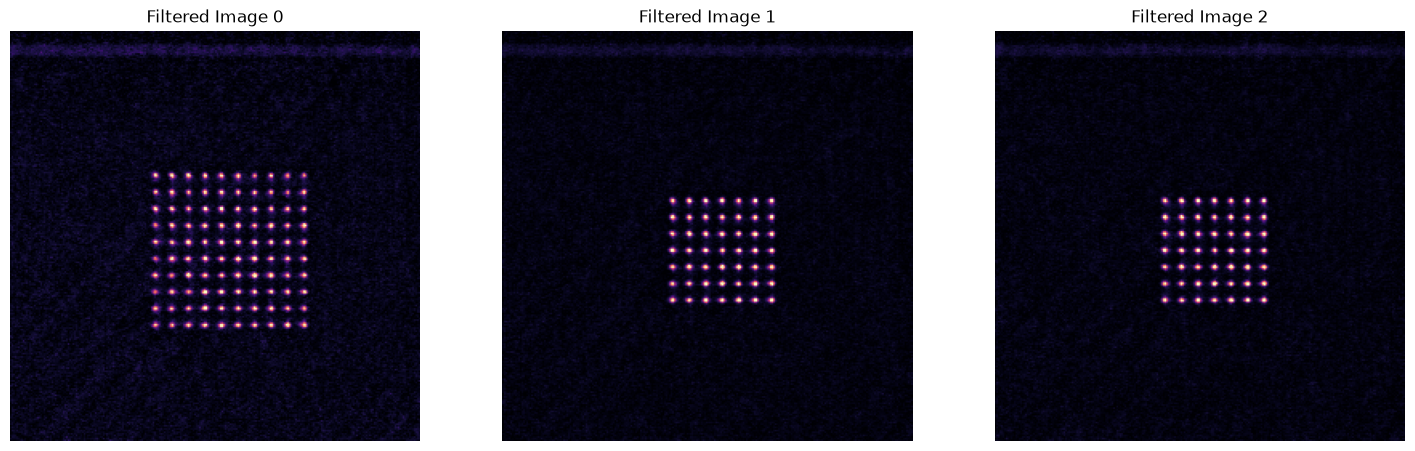

In [69]:
num_imgs_per_it = 3
tot_imgs = np.array(imgs_software)

plt.figure(figsize=(6*num_imgs_per_it, 6))
for n in range(num_imgs_per_it):
    imgs_n = tot_imgs[:, n, :, :]
    imgs__n_mean = imgs_n.mean(axis=0)
    imgs_n_mean_filtered = an.morphological_tophat_high_pass(imgs__n_mean, feature_size=feature_size)

    plt.subplot(1, num_imgs_per_it, n + 1)
    plt.imshow(imgs_n_mean_filtered, cmap='magma', vmax=0.6*imgs_n_mean_filtered.max())
    plt.title(f'Filtered Image {n}')
    plt.axis('off')
    
plt.show()

  calculation + upload:   3.88 ms fixed + 0.680 ms/frame (residual sd 0.432 ms)
                 total:   4.06 ms fixed + 0.681 ms/frame (residual sd 0.440 ms)

ratio total/n_frames = 0.881 ms/frame over n_frames 16-26


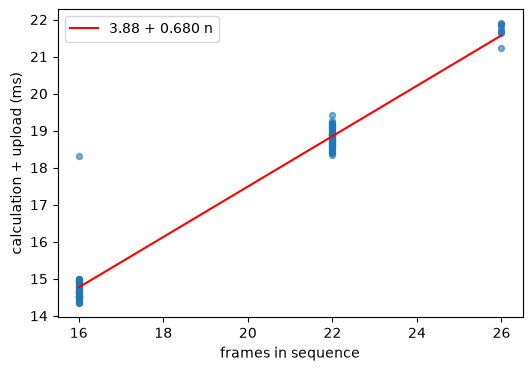

In [21]:
n_frames = np.array([t['n_frames'] for t in timings_log], dtype=float)
calc_upload_ms = np.array([t['calculation_and_upload_ms'] for t in timings_log])
total_ms = np.array([t['total_rearrangement_ms'] for t in timings_log])

if len(np.unique(n_frames)) < 2:
    print(f"All shots used {n_frames[0]:.0f} frames - cannot separate fixed from per-frame cost.")
else:
    for label, y in (("calculation + upload", calc_upload_ms), ("total", total_ms)):
        per_frame, fixed = np.polyfit(n_frames, y, 1)
        residual = y - (fixed + per_frame * n_frames)
        print(f"{label:>22}: {fixed:6.2f} ms fixed + {per_frame:.3f} ms/frame "
              f"(residual sd {residual.std():.3f} ms)")
    print(f"\nratio total/n_frames = {(calc_upload_ms / n_frames).mean():.3f} ms/frame "
          f"over n_frames {n_frames.min():.0f}-{n_frames.max():.0f}")

    plt.figure(figsize=(6, 4))
    plt.scatter(n_frames, calc_upload_ms, s=18, alpha=0.6)
    fit_x = np.array([n_frames.min(), n_frames.max()])
    per_frame, fixed = np.polyfit(n_frames, calc_upload_ms, 1)
    plt.plot(fit_x, fixed + per_frame * fit_x, 'r-',
             label=f"{fixed:.2f} + {per_frame:.3f} n")
    plt.xlabel("frames in sequence")
    plt.ylabel("calculation + upload (ms)")
    plt.legend()
    plt.show()

Looking for trap sites...
7x7 array detected.


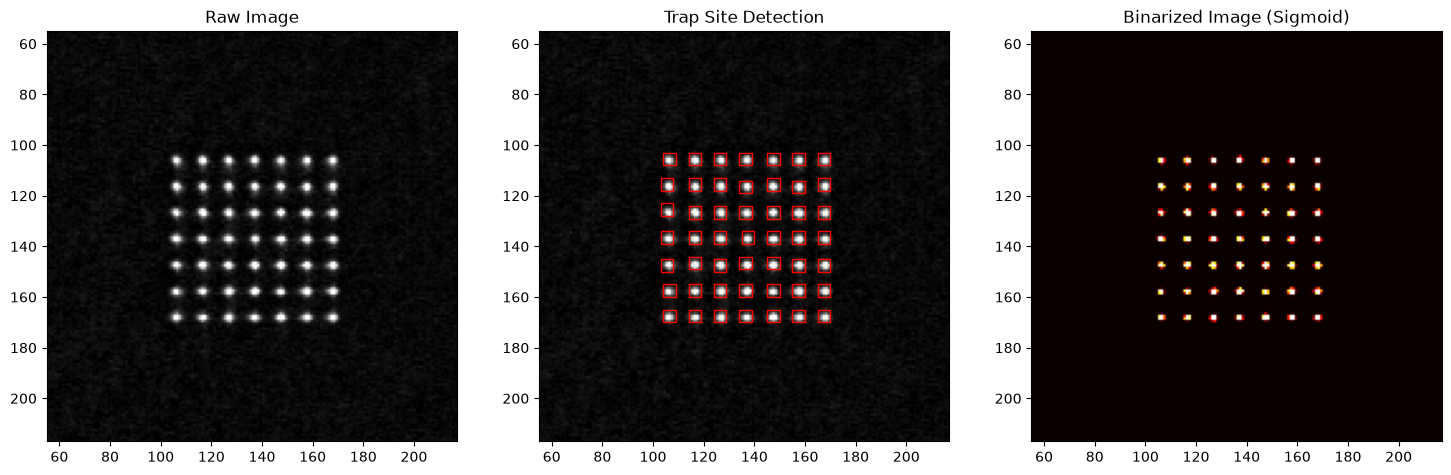

Trap (0, 0) Loading Probability : 98.00 %
Trap (0, 1) Loading Probability : 97.00 %
Trap (0, 2) Loading Probability : 97.00 %
Trap (0, 3) Loading Probability : 95.00 %
Trap (0, 4) Loading Probability : 96.00 %
Trap (0, 5) Loading Probability : 98.00 %
Trap (0, 6) Loading Probability : 95.00 %
Trap (1, 0) Loading Probability : 97.00 %
Trap (1, 1) Loading Probability : 94.00 %
Trap (1, 2) Loading Probability : 96.00 %
Trap (1, 3) Loading Probability : 93.00 %
Trap (1, 4) Loading Probability : 92.00 %
Trap (1, 5) Loading Probability : 97.00 %
Trap (1, 6) Loading Probability : 94.00 %
Trap (2, 0) Loading Probability : 90.00 %
Trap (2, 1) Loading Probability : 99.00 %
Trap (2, 2) Loading Probability : 96.00 %
Trap (2, 3) Loading Probability : 93.00 %
Trap (2, 4) Loading Probability : 92.00 %
Trap (2, 5) Loading Probability : 95.00 %
Trap (2, 6) Loading Probability : 99.00 %
Trap (3, 0) Loading Probability : 95.00 %
Trap (3, 1) Loading Probability : 95.00 %
Trap (3, 2) Loading Probability : 

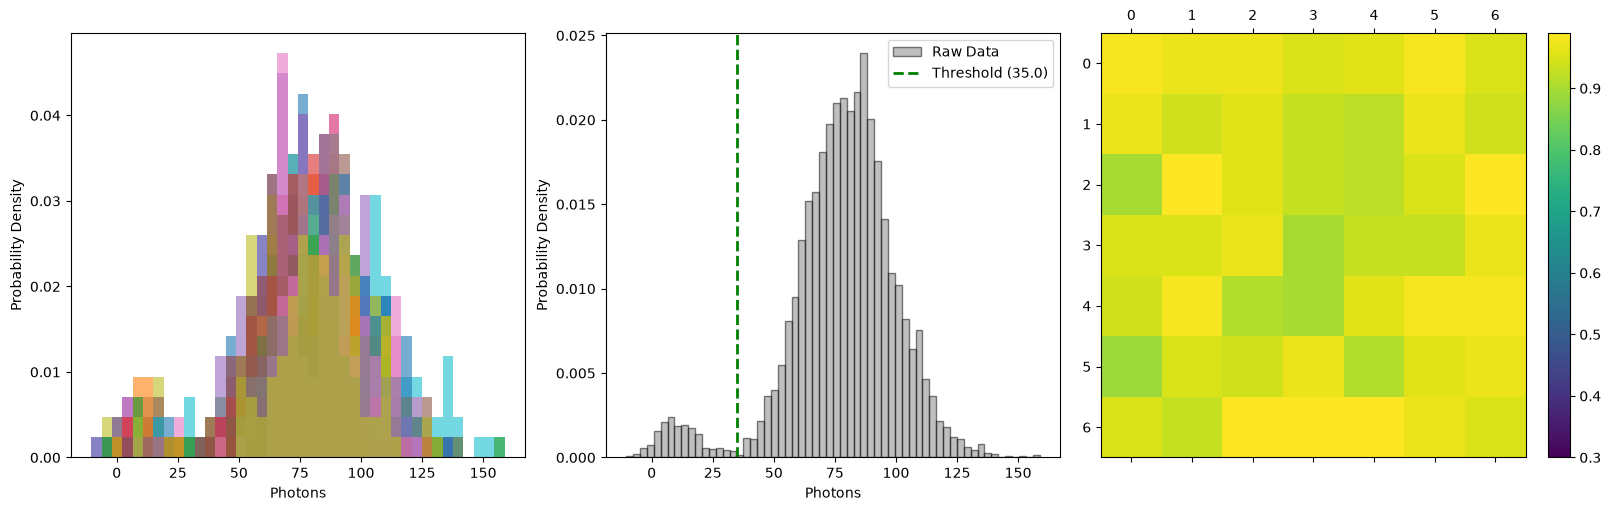

In [74]:
n = 1
imgs_n = tot_imgs[:, n, :, :]
imgs__n_mean = imgs_n.mean(axis=0)
imgs_n_mean_filtered = an.morphological_tophat_high_pass(imgs__n_mean, feature_size=feature_size)
array_shape_n = [7, 7]

window, feature_size = 5, 10
grid_positions_2, detection_threshold = an.detect_trap_sites(imgs_n_mean_filtered, array_shape_n, detection_step=100)
an.visualize_results(imgs_n_mean_filtered, grid_positions_2, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)

imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs_n]
photon_rates, loading_probabilities, threshold_2, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions_2, array_shape_n, threshold_detection=False, threshold=35, window_size=window, binning=60)

Looking for trap sites...
7x7 array detected.


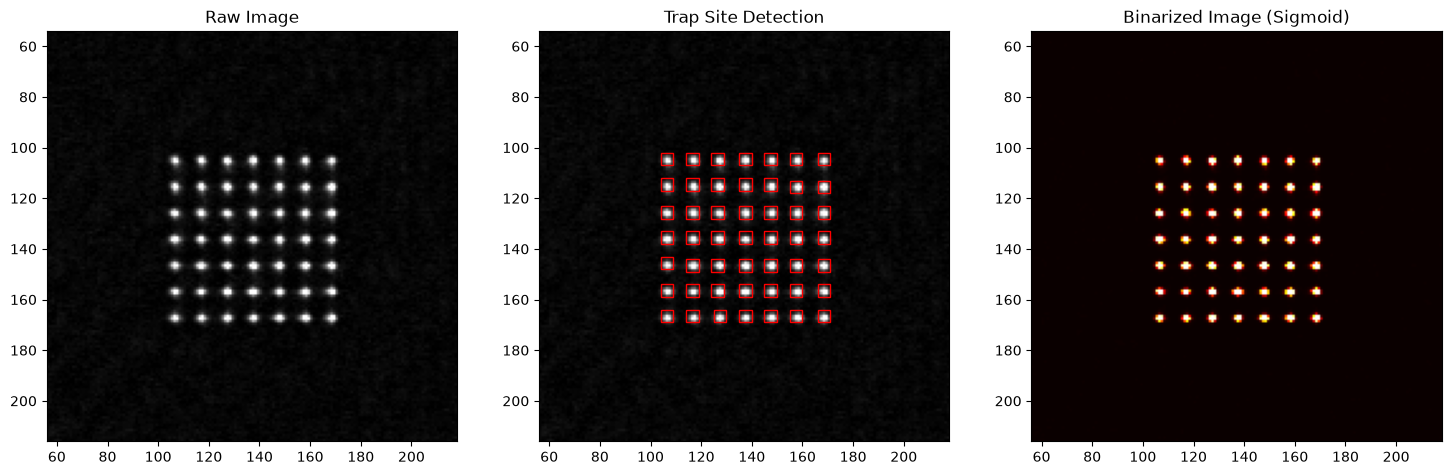

Trap (0, 0) Loading Probability : 95.74 %
Trap (0, 1) Loading Probability : 95.21 %
Trap (0, 2) Loading Probability : 94.15 %
Trap (0, 3) Loading Probability : 96.81 %
Trap (0, 4) Loading Probability : 94.68 %
Trap (0, 5) Loading Probability : 97.87 %
Trap (0, 6) Loading Probability : 91.49 %
Trap (1, 0) Loading Probability : 95.74 %
Trap (1, 1) Loading Probability : 95.21 %
Trap (1, 2) Loading Probability : 96.81 %
Trap (1, 3) Loading Probability : 93.09 %
Trap (1, 4) Loading Probability : 96.81 %
Trap (1, 5) Loading Probability : 97.87 %
Trap (1, 6) Loading Probability : 96.81 %
Trap (2, 0) Loading Probability : 92.55 %
Trap (2, 1) Loading Probability : 94.15 %
Trap (2, 2) Loading Probability : 94.68 %
Trap (2, 3) Loading Probability : 94.15 %
Trap (2, 4) Loading Probability : 94.68 %
Trap (2, 5) Loading Probability : 96.28 %
Trap (2, 6) Loading Probability : 96.81 %
Trap (3, 0) Loading Probability : 95.74 %
Trap (3, 1) Loading Probability : 95.74 %
Trap (3, 2) Loading Probability : 

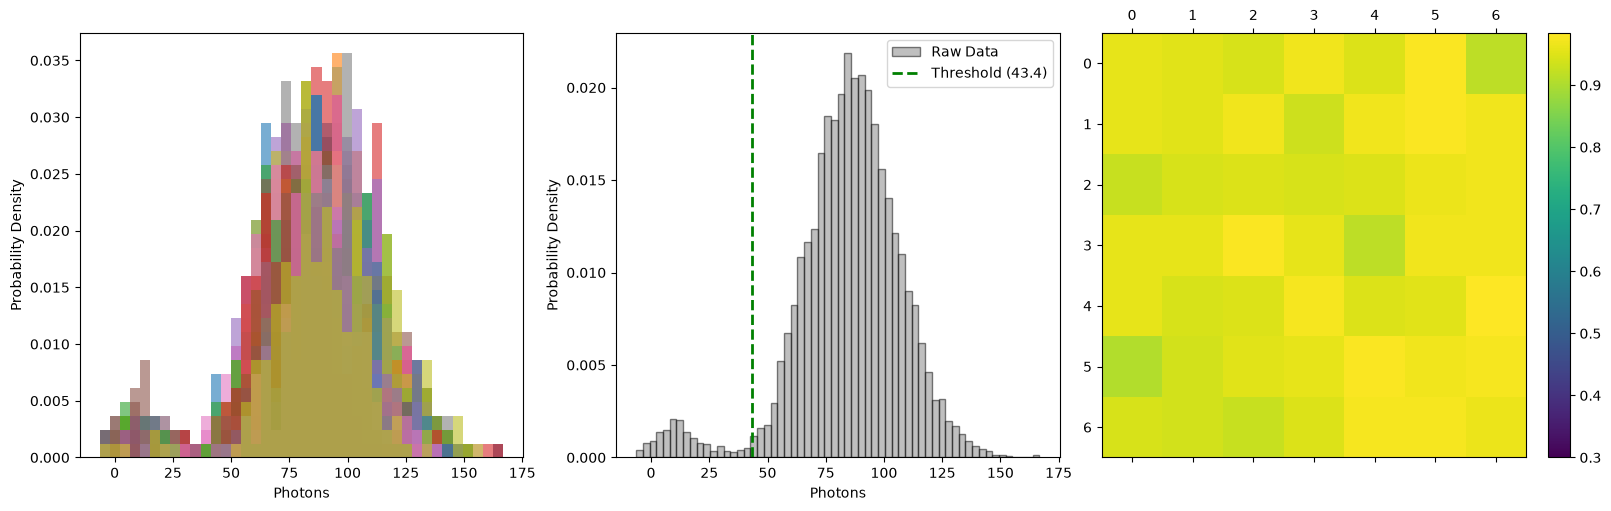

In [397]:
array_shape_2 = [7, 7]
window = 5
feature_size = 10

grid_positions_2, detection_threshold = an.detect_trap_sites(imgs1_mean_filtered, array_shape_2, detection_step=200)
an.visualize_results(imgs1_mean_filtered, grid_positions_2, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)

imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
photon_rates, loading_probabilities, _, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions_2, array_shape_2, threshold_detection=False, threshold=threshold_1, window_size=window, binning=60)

In [392]:
loading_probabilities.mean() / baseline_survival_probability

np.float64(0.9901739759523527)

#### Save Data

In [ ]:
tot_rearrangement_times = np.array([t['total_rearrangement_ms'] for t in timings_log])
calc_upload_times = np.array([t['calculation_and_upload_ms'] for t in timings_log])
occupancy_extraction_times = np.array([t['occupancy_extraction_ms'] for t in timings_log])
n_frames = np.array([t['n_frames'] for t in timings_log])

dataset_title = "rearrangement_10x10_7x7_2"

os.makedirs(os.path.join(data_dir, dataset_title), exist_ok=True)

# Save tot_rearrangement_times, calc_upload_times, occupancy_extraction_times, n_frames, imgs0, imgs1 to a pickle file
with open(os.path.join(data_dir, dataset_title, "timing_and_images.pkl"), "wb") as f:
    pickle.dump({
        "tot_rearrangement_times": tot_rearrangement_times,
        "calc_upload_times": calc_upload_times,
        "occupancy_extraction_times": occupancy_extraction_times,
        "n_frames": n_frames,
        "imgs0": imgs0,
        "imgs1": imgs1
    }, f)

In [53]:
# Save contextual information about the experiment to a text file
with open(os.path.join(data_dir, dataset_title, "experiment_info.txt"), "w") as f:
    f.write(f"Dataset Title: {dataset_title}\n")
    f.write(f"Date: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"""
    50 ms time slot given for rearrangement with a baseline survival probability of {baseline_survival_probability:.6f}.
    Rearrangement parameters: d0 = 0.5, threshold = {threshold_count*1.1:.4f} photons, profile = linear, window_size = 5, feature_size = 10.
    Occupancy extraction using the PSF method.
    """)

In [52]:
# Create a subdirectory called intial images and one for final images
os.makedirs(os.path.join(data_dir, dataset_title, "initial_images"), exist_ok=True)
os.makedirs(os.path.join(data_dir, dataset_title, "final_images"), exist_ok=True)

# Save the initial and final images to the respective directories as .tif files
import tifffile

for i, img in enumerate(imgs0):
    tifffile.imwrite(os.path.join(data_dir, dataset_title, "initial_images", f"initial_img_{i:04d}.tif"), img)

for i, img in enumerate(imgs1):
    tifffile.imwrite(os.path.join(data_dir, dataset_title, "final_images", f"final_img_{i:04d}.tif"), img)

---

## Rearrangement Exp 2

In [ ]:
import asyncio
from pytweezer.coordinators.rearrangement import Rearrangement
import time

coordinator = Rearrangement({"camera": hamcam, "slm": slm, "phasemask_generator": PM}, {})

data1, array_shape1 = np.stack(terms1[:4]), terms1[4]
data2, array_shape2 = np.stack(terms2[:4]), terms2[4]

Occupancy via PSF detector (window 9, threshold 3.3).
Rearrangement node initialised.


In [55]:
# Experiment and camera setup
n_iterations = 1
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)

{'ok': True,
 'command': 'interface_method',
 'method': 'set_run_until_stopped',
 'state': 'accepted'}

In [56]:
N_iterations = 200  # adjust before running

step_sizes = np.linspace(0.5, 2.0, 10)

img_data = []
timing_data = []

for d0 in step_sizes:
    await asyncio.to_thread(
        coordinator.initialise,
        data1, data2, array_shape1, array_shape2,
        d0=d0, fps=1/(1e-6), threshold=threshold_count*1.1,
        grid_positions=grid_positions_1, profile="linear", window_size=5, feature_size=10, 
        detector=scorer
    )

    imgs_software = []
    err_indices = []
    timings_log = []

    for it in range(N_iterations):
        print(f"Running experiment iteration {it+1} / {N_iterations}")
        rearrangement_task = asyncio.create_task(asyncio.to_thread(coordinator.arm_rearrangement))

        time.sleep(0.1)
        exp.start_motmaster_experiment({
                    "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
                    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
                    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
                    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
                    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
                    "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
                    "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
                    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
                    "BackgroundDrop": 0})
        img0, img1, timings = await rearrangement_task
        print("Images acquired from rearrangement node.")

        if img1.sum() == 0:
            print(f"Empty image received at iteration {it+1}. Discarding...")
            err_indices.append(it)
        else:
            imgs_software.append([img0, img1])
            timings_log.append(timings)

    mean_rearrangement_time_ms = np.mean([t['total_rearrangement_ms'] for t in timings_log])
    mean_calc_upload_time_ms = np.mean([t['calculation_and_upload_ms'] for t in timings_log])
    mean_nframes = np.mean([t['n_frames'] for t in timings_log])
    mean_speed = mean_rearrangement_time_ms / mean_nframes
    mean_calc_upload_speed = mean_calc_upload_time_ms / mean_nframes

    timing_data.append(timings_log)
    img_data.append(imgs_software)

    print(f"d0 = {d0:.2f}: Average total rearrangement time = {mean_rearrangement_time_ms:.2f} ms, Average number of frames = {mean_nframes:.2f}, Average total speed = {mean_speed:.2f} ms/frame, Average calculation and upload speed = {mean_calc_upload_speed:.2f} ms/frame")

Occupancy via PSF detector (window 9, threshold 3.3).
Rearrangement node initialised.
Running experiment iteration 1 / 200
Rearrangement complete: 22 frames, 19.5373ms total (occupancy 0.3314ms, calculation+upload 19.2059ms).
Images acquired from rearrangement node.
Running experiment iteration 2 / 200
Rearrangement complete: 22 frames, 18.8987ms total (occupancy 0.1618ms, calculation+upload 18.7369ms).
Images acquired from rearrangement node.
Running experiment iteration 3 / 200
Rearrangement complete: 16 frames, 14.6490ms total (occupancy 0.1354ms, calculation+upload 14.5136ms).
Images acquired from rearrangement node.
Running experiment iteration 4 / 200
Rearrangement complete: 16 frames, 14.9878ms total (occupancy 0.1370ms, calculation+upload 14.8508ms).
Images acquired from rearrangement node.
Running experiment iteration 5 / 200
Rearrangement complete: 16 frames, 14.5521ms total (occupancy 0.1332ms, calculation+upload 14.4189ms).
Images acquired from rearrangement node.
Running e

In [59]:
rearrangement_efficiencies = []
for i, d0 in enumerate(step_sizes):
    tot_imgs = np.array(img_data[i])
    imgs0 = tot_imgs[:, 0, :, :]
    imgs1 = tot_imgs[:, 1, :, :]    
    imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
    photon_rates, loading_probabilities, _, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions_2, array_shape_2, threshold_detection=False, threshold=threshold_2, window_size=window, binning=60, show_histogram=False, verbose=False)
    filling_fraction = np.mean(loading_probabilities)
    rearrangement_efficiency = filling_fraction / baseline_survival_probability
    print(f"d0 = {d0:.2f}: Filling fraction = {filling_fraction:.4f}, Rearrangement efficiency = {rearrangement_efficiency:.4f}")
    rearrangement_efficiencies.append(rearrangement_efficiency)

d0 = 0.50: Filling fraction = 0.9619, Rearrangement efficiency = 0.9920
d0 = 0.67: Filling fraction = 0.9616, Rearrangement efficiency = 0.9917
d0 = 0.83: Filling fraction = 0.9657, Rearrangement efficiency = 0.9959
d0 = 1.00: Filling fraction = 0.9604, Rearrangement efficiency = 0.9904
d0 = 1.17: Filling fraction = 0.9550, Rearrangement efficiency = 0.9848
d0 = 1.33: Filling fraction = 0.9283, Rearrangement efficiency = 0.9573
d0 = 1.50: Filling fraction = 0.9249, Rearrangement efficiency = 0.9538
d0 = 1.67: Filling fraction = 0.8666, Rearrangement efficiency = 0.8937
d0 = 1.83: Filling fraction = 0.8111, Rearrangement efficiency = 0.8365
d0 = 2.00: Filling fraction = 0.7735, Rearrangement efficiency = 0.7976


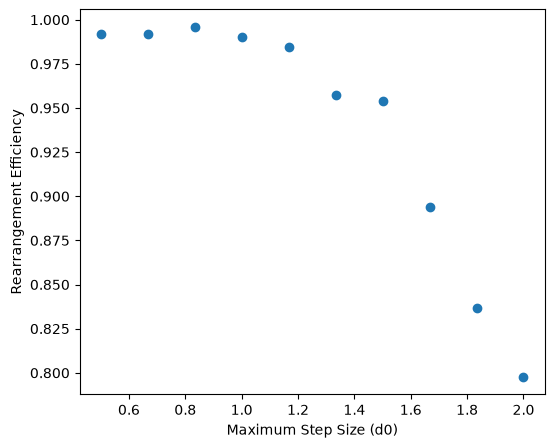

In [83]:
from scipy.optimize import curve_fit

x_data = step_sizes
y_data = rearrangement_efficiencies

plt.figure(figsize=(6, 5))
plt.scatter(x_data, y_data)
plt.xlabel("Maximum Step Size (d0)")
plt.ylabel("Rearrangement Efficiency")
plt.show()

In [67]:
n_frames_data = []
calc_upload_time_data = []
total_rearrangement_time_data = []
for i, d0 in enumerate(step_sizes):
    timings_log = timing_data[i]
    for t in timings_log:
        n_frames = t['n_frames']
        calc_upload_time = t['calculation_and_upload_ms']
        tot_rearrangement_time = t['total_rearrangement_ms']
        n_frames_data.append(n_frames)
        calc_upload_time_data.append(calc_upload_time)
        total_rearrangement_time_data.append(tot_rearrangement_time)

  calculation + upload:   3.48 ms fixed + 0.699 ms/frame (residual sd 0.237 ms)
                 total:   3.68 ms fixed + 0.698 ms/frame (residual sd 0.245 ms)

ratio total/n_frames = 1.122 ms/frame over n_frames 4-30


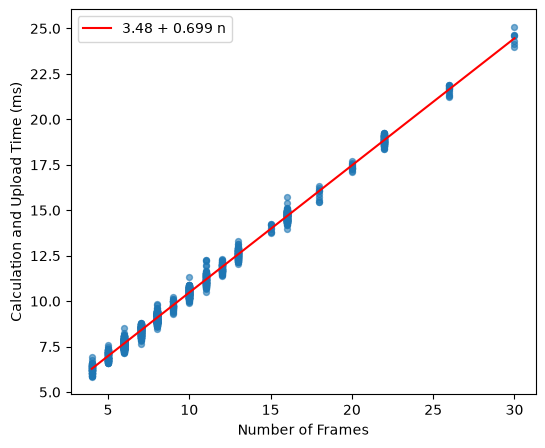

In [82]:
n_frames = np.array(n_frames_data)
calc_upload_ms = np.array(calc_upload_time_data)
total_ms = np.array(total_rearrangement_time_data)

if len(np.unique(n_frames)) < 2:
    print(f"All shots used {n_frames[0]:.0f} frames - cannot separate fixed from per-frame cost.")
else:
    for label, y in (("calculation + upload", calc_upload_ms), ("total", total_ms)):
        per_frame, fixed = np.polyfit(n_frames, y, 1)
        residual = y - (fixed + per_frame * n_frames)
        print(f"{label:>22}: {fixed:6.2f} ms fixed + {per_frame:.3f} ms/frame "
              f"(residual sd {residual.std():.3f} ms)")
    print(f"\nratio total/n_frames = {(calc_upload_ms / n_frames).mean():.3f} ms/frame "
          f"over n_frames {n_frames.min():.0f}-{n_frames.max():.0f}")

    plt.figure(figsize=(6, 5))
    plt.scatter(n_frames, calc_upload_ms, s=18, alpha=0.6)
    fit_x = np.array([n_frames.min(), n_frames.max()])
    per_frame, fixed = np.polyfit(n_frames, calc_upload_ms, 1)
    plt.plot(fit_x, fixed + per_frame * fit_x, 'r-',
             label=f"{fixed:.2f} + {per_frame:.3f} n")
             
    plt.xlabel("Number of Frames")
    plt.ylabel("Calculation and Upload Time (ms)")
    plt.legend()
    plt.show()

Fit parameters: per_frame_time = 0.699 ± 0.001 ms/frame, fixed_time = 3.48 ± 0.01 ms


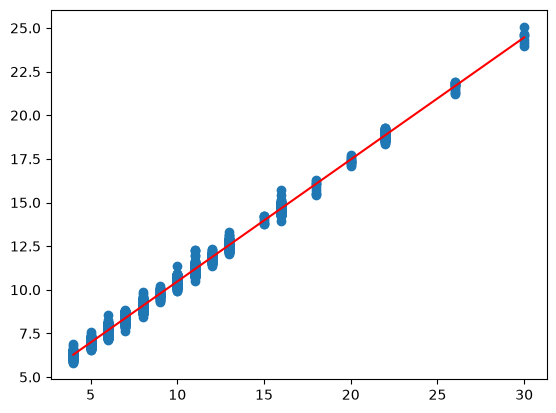

In [85]:
x_data = n_frames
y_data = calc_upload_ms

lin_fit = lambda x, m, b: m * x + b

popt, pcov = curve_fit(lin_fit, x_data, y_data)
x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit = lin_fit(x_fit, *popt)
plt.scatter(x_data, y_data, label='Data')
plt.plot(x_fit, y_fit, 'r-', label=f'Fit: y = {popt[0]:.3f}x + {popt[1]:.2f}')

# Print the fit parameters and their uncertainties
per_frame_time = popt[0]
fixed_time = popt[1]
per_frame_time_err = np.sqrt(pcov[0][0])
fixed_time_err = np.sqrt(pcov[1][1])
print(f"Fit parameters: per_frame_time = {per_frame_time:.3f} ± {per_frame_time_err:.3f} ms/frame, fixed_time = {fixed_time:.2f} ± {fixed_time_err:.2f} ms")

In [86]:
dataset_dir = os.path.join(data_dir, "rearrangement_step_size_scans")
for i, d0 in enumerate(step_sizes):
    dataset_title = f"rearrangement_d0_{d0:.2f}"
    os.makedirs(os.path.join(dataset_dir, dataset_title), exist_ok=True)

    # Save timing_data and img_data to a pickle file
    with open(os.path.join(dataset_dir, dataset_title, "timing_and_images.pkl"), "wb") as f:
        pickle.dump({
            "timing_data": timing_data[i],
            "img_data": img_data[i]
        }, f)

    # Save contextual information about the experiment to a text file
    with open(os.path.join(dataset_dir, dataset_title, "experiment_info.txt"), "w") as f:
        f.write(f"Dataset Title: {dataset_title}\n")
        f.write(f"Date: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"""
        Rearrangement parameters: d0 = {d0:.2f}, threshold = {threshold_count*1.1:.4f} photons, profile = linear, window_size = 5, feature_size = 10.
        Occupancy extraction using the PSF method.
        """)

---

In [103]:
dataset_dir = os.path.join(data_dir, "rearrangement_step_size_scans")

speeds = []
nframes_list = []

for dir in os.listdir(dataset_dir):
    if dir.startswith("rearrangement_d0_"):
        d0_value = float(dir.split("_")[-1])
        with open(os.path.join(dataset_dir, dir, "timing_and_images.pkl"), "rb") as f:
            data = pickle.load(f)
            timings_log = data["timing_data"]
            imgs_software = data["img_data"]
        for t in timings_log:
            nframes = t['n_frames']
            calc_upload_time = t['calculation_and_upload_ms']
            speed = calc_upload_time / nframes
            speeds.append(speed)
            nframes_list.append(nframes)

speeds = np.array(speeds)
nframes_array = np.array(nframes_list)

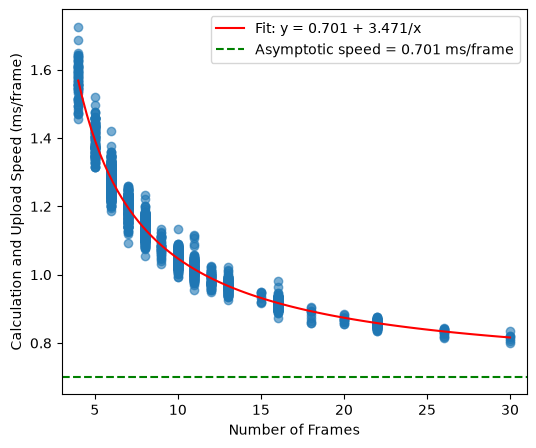

In [112]:
from scipy.optimize import curve_fit

x_data = nframes_array
y_data = speeds

# Fit an exponential decay function to the data
def fit_func(x, m, c):
    return m + c / x

plt.figure(figsize=(6, 5))
popt, pcov = curve_fit(fit_func, x_data, y_data, p0=[0.699, 3.48])
xfit = np.linspace(min(x_data), max(x_data), 100)
yfit = fit_func(xfit, *popt)
plt.scatter(nframes_array, speeds, alpha=0.6)
plt.plot(xfit, yfit, 'r-', label=f'Fit: y = {popt[0]:.3f} + {popt[1]:.3f}/x')
plt.xlim(min(x_data)-1, max(x_data)+1)
plt.hlines(popt[0], min(x_data)-1, max(x_data)+1, colors='g', linestyles='dashed', label=f'Asymptotic speed = {popt[0]:.3f} ms/frame')
plt.xlabel("Number of Frames")
plt.ylabel("Calculation and Upload Speed (ms/frame)")
plt.legend()

---
## Simulation

In [245]:
dx, dy = 8.0, 12.0
PM = pm.OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=17.3,
                 slm_pitch_um=17,
                 slm_res=(1024,1024),
                 input_beam_waist_mm=16,
                 fresnel_f_mm=1072,
                 blaze_dx_dy_um=(40+dx, -8+dy),
                 zernike_coeff_dict={5:1.195, 6:0.725, 7:0.970, 8:0.478, 9:-1.091, 10:0.303, 11:0.021, 12:0.072, 13:0.049})

gauss2d = lambda x, y, A, x0, y0, sx, sy, offset: (A * np.exp(-(((x - x0) ** 2) / (2 * sx ** 2) + ((y - y0) ** 2) / (2 * sy ** 2)))) + offset
A, x0, y0, sx, sy, offset = [-2.14197604e+03, -1.11443850e+01 - dx, 2.09919600e+00 - dy, 2.95002910e+03, 2.64281503e+03, 2.14239505e+03]

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (48.0, 4.0) um


Initial array

--- Target Generation ---
Grid: 20x20
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 9.51e-07 | Uniformity: 60.99% | Min/Max ratio: 0.062
Iteration 010 | Mean-Squared Error: 1.53e-08 | Uniformity: 95.05% | Min/Max ratio: 0.741
Iteration 020 | Mean-Squared Error: 2.25e-09 | Uniformity: 98.10% | Min/Max ratio: 0.890
Iteration 030 | Mean-Squared Error: 1.00e-09 | Uniformity: 98.73% | Min/Max ratio: 0.930
Iteration 040 | Mean-Squared Error: 5.91e-10 | Uniformity: 99.03% | Min/Max ratio: 0.939
Iteration 050 | Mean-Squared Error: 5.99e-10 | Uniformity: 99.02% | Min/Max ratio: 0.945
Iteration 060 | Mean-Squared Error: 2.20e-10 | Uniformity: 99.41% | Min/Max ratio: 0.958
Iteration 070 | Mean-Squared Error: 8.51e-11 | Uniformity: 99.63% | Min/Max ratio: 0.978
Iteration 080 | Mean-Squared Error: 3.71e-11 | Uniformity: 99.76% | Min/Max ratio: 0.986
Iteration 090 | Mean-Squared Error: 3.22e-11 | Uniformity: 99.77% | Min/Max ratio: 0.987
Itera

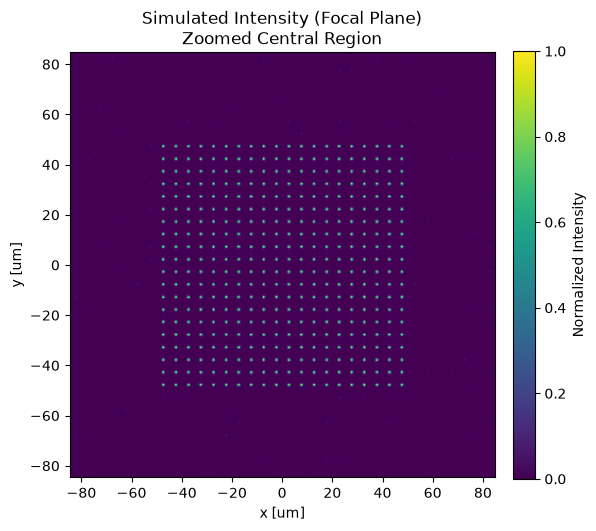

In [290]:
arr1 = (20, 20)
W1 = np.ones(arr1)
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W1, spacing_um, init_phase_randomness=1.0, angle_deg=0.0)
terms1 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array1, terms1, _ = PM.superposition_optimization(terms1, max_iter=2000, damping=0.5, verbose=True)
_ = PM.simulate_focal_plane(pm_array1, Nx_pad=2048, Ny_pad=2048, zoom_pixels=100, show=True)

Second array

--- Target Generation ---
Grid: 14x14
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 3.04e-06 | Uniformity: 65.81% | Min/Max ratio: 0.139
Iteration 010 | Mean-Squared Error: 5.46e-08 | Uniformity: 95.42% | Min/Max ratio: 0.734
Iteration 020 | Mean-Squared Error: 7.78e-09 | Uniformity: 98.27% | Min/Max ratio: 0.908
Iteration 030 | Mean-Squared Error: 2.16e-09 | Uniformity: 99.09% | Min/Max ratio: 0.943
Iteration 040 | Mean-Squared Error: 1.06e-09 | Uniformity: 99.36% | Min/Max ratio: 0.965
Iteration 050 | Mean-Squared Error: 9.25e-10 | Uniformity: 99.40% | Min/Max ratio: 0.970
Iteration 060 | Mean-Squared Error: 6.26e-10 | Uniformity: 99.51% | Min/Max ratio: 0.972
Iteration 070 | Mean-Squared Error: 5.82e-10 | Uniformity: 99.53% | Min/Max ratio: 0.974
Iteration 080 | Mean-Squared Error: 4.37e-10 | Uniformity: 99.59% | Min/Max ratio: 0.978
Iteration 090 | Mean-Squared Error: 4.11e-10 | Uniformity: 99.60% | Min/Max ratio: 0.978
Itera

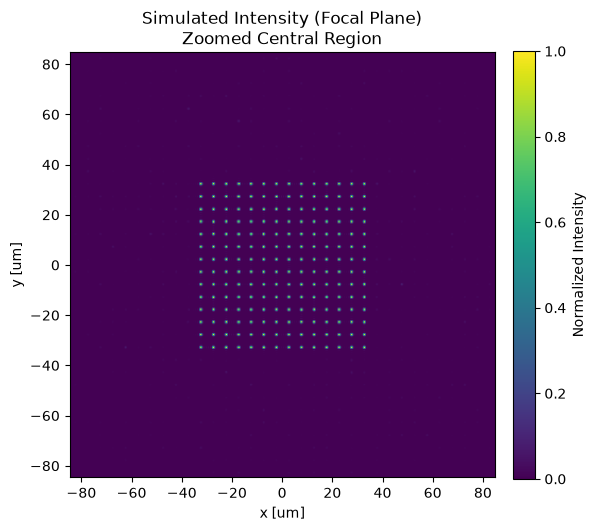

In [296]:
arr2 = (14, 14)
W2 = np.ones(arr2)
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W2, spacing_um, init_phase_randomness=1.0, angle_deg=0.0)
terms2 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array2, terms2, _ = PM.superposition_optimization(terms2, max_iter=5000, damping=0.5, verbose=True)
_ = PM.simulate_focal_plane(pm_array2, Nx_pad=2048, Ny_pad=2048, zoom_pixels=100, show=True)

In [297]:
import cupy as cp
from pytweezer.phasemask import get_jv_pairing_lap

def iter_rearrangement_sequence(terms1, terms2, occ_mask, d0=0.5,
                                profile="linear"):

    if profile not in ("minimum_jerk", "linear"):
        raise ValueError(
            f"profile must be 'minimum_jerk' or 'linear', got {profile!r}"
        )
    w1, phi1, x1, y1, arr1 = terms1
    w2, phi2, x2, y2, _ = terms2
    occ_mask = cp.asarray(occ_mask)

    pos1 = cp.stack((x1, y1), axis=-1)
    pos2 = cp.stack((x2, y2), axis=-1)

    occ_indices = cp.where(occ_mask)[0]
    init = pos1[occ_indices]
    final = pos2

    init_idx, final_idx = get_jv_pairing_lap(init, final)
    moving_idx = occ_indices[init_idx]

    off_mask = cp.ones(len(pos1), dtype=bool)
    off_mask[moving_idx] = False

    pos_init = pos1[moving_idx]
    pos_final = pos2[final_idx]
    vec = pos_final - pos_init

    max_dist = cp.linalg.norm(vec, axis=1).max()
    steps_scale = 1.0 if profile == "linear" else 1.875
    n_steps = int(cp.ceil(steps_scale * max_dist / d0))

    curr_w = cp.asarray(w1, dtype=cp.float32)
    curr_phi = cp.asarray(phi1, dtype=cp.float32)
    curr_x = cp.asarray(x1, dtype=cp.float32)
    curr_y = cp.asarray(y1, dtype=cp.float32)

    tau = cp.linspace(0, 1, n_steps + 1, dtype=cp.float32)
    if profile == "linear":
        s_profile = tau
    else:
        s_profile = 10 * tau**3 - 15 * tau**4 + 6 * tau**5
    ds_profile_cpu = cp.diff(s_profile).get()

    dw = cp.zeros_like(curr_w)
    dphi = cp.zeros_like(curr_phi)
    total_dx = cp.zeros_like(curr_x)
    total_dy = cp.zeros_like(curr_y)

    w1_gpu, w2_gpu = cp.asarray(w1), cp.asarray(w2)
    phi1_gpu, phi2_gpu = cp.asarray(phi1), cp.asarray(phi2)

    dw[moving_idx] = (w2_gpu[final_idx] - w1_gpu[moving_idx]) / n_steps
    total_dx[moving_idx] = vec[:, 0].astype(cp.float32)
    total_dy[moving_idx] = vec[:, 1].astype(cp.float32)

    phase_diff = (phi2_gpu[final_idx] - phi1_gpu[moving_idx] + cp.pi) % (2 * cp.pi) - cp.pi
    dphi[moving_idx] = phase_diff / n_steps

    dw[off_mask] = 0.0
    curr_w[off_mask] = 0.0

    w_list, phi_list, x_list, y_list = [], [], [], []
    pm_slm_sequence = []

    for n in range(n_steps):
        ds = float(ds_profile_cpu[n])
        update_state_kernel(dw, dphi, total_dx, total_dy, ds, curr_w, curr_phi, curr_x, curr_y)
        terms_gpu = (curr_w, curr_phi, curr_x, curr_y, arr1)
        pm_slm = PM.generate_phasemask(terms_gpu)
        
        w_list.append(curr_w.get())
        phi_list.append(curr_phi.get())
        x_list.append(curr_x.get())
        y_list.append(curr_y.get())
        pm_slm_sequence.append(pm_slm.get())

    w_array = np.array(w_list)
    phi_array = np.array(phi_list)
    x_array = np.array(x_list)
    y_array = np.array(y_list)
    pm_slm_array = np.array(pm_slm_sequence)
        
    return w_array, phi_array, x_array, y_array, pm_slm_array

# Define this fused kernel outside the loop (or at the module level).
# CuPy will compile it once on the first run and cache it, saving massive
# overhead by doing 4 state updates in a single GPU kernel launch.
update_state_kernel = cp.ElementwiseKernel(
'float32 dw, float32 dphi, float32 dx, float32 dy, float32 ds',
'float32 w, float32 phi, float32 x, float32 y',
'''
w += dw;
phi += dphi;
x += dx * ds;
y += dy * ds;
''',
'update_hologram_state'
)

def evaluate_trap_fields(pm_slm, x_n, y_n):
    am_slm = cp.asarray(PM.generate_source_amplitude())

    pm_slm = cp.asarray(pm_slm)
    x_n_cp = cp.asarray(x_n)
    y_n_cp = cp.asarray(y_n)

    X_phase = cp.exp(PM.j_k * x_n_cp[:, None] * PM.x_slm[None, :]) # Shape: (N_traps, Nx)
    Y_phase = cp.exp(PM.j_k * y_n_cp[:, None] * PM.y_slm[None, :]) # Shape: (N_traps, Ny)
    X_phase_conj = cp.conj(X_phase)
    Y_phase_conj = cp.conj(Y_phase)

    X_phase_conj = cp.conj(X_phase)
    Y_phase_conj = cp.conj(Y_phase)
    
    U_slm = am_slm * cp.exp(1j * pm_slm)
    U_foc_n = U_slm @ X_phase_conj.T # Shape: (Ny, Nx) @ (Nx, N_traps) -> (Ny, N_traps)
    U_foc = cp.sum(Y_phase_conj * U_foc_n.T, axis=1) # Shape: (N_traps,)
    w_foc = cp.abs(U_foc)
    phi_foc = cp.angle(U_foc)
    I_foc = w_foc**2
    return I_foc.get(), phi_foc.get()

In [310]:
def iter_rearrangement_sequence(terms1, terms2, occ_mask, d0=0.5,
                                profile="linear"):

    if profile not in ("minimum_jerk", "linear"):
        raise ValueError(
            f"profile must be 'minimum_jerk' or 'linear', got {profile!r}"
        )

    w1, phi1, x1, y1, arr1 = terms1
    w2, phi2, x2, y2, _ = terms2
    occ_mask = cp.asarray(occ_mask)

    pos1 = cp.stack((x1, y1), axis=-1)
    pos2 = cp.stack((x2, y2), axis=-1)

    occ_indices = cp.where(occ_mask)[0]
    init = pos1[occ_indices]
    final = pos2

    init_idx, final_idx = get_jv_pairing_lap(init, final)
    moving_idx = occ_indices[init_idx]

    off_mask = cp.ones(len(pos1), dtype=bool)
    off_mask[moving_idx] = False

    pos_init = pos1[moving_idx]
    pos_final = pos2[final_idx]
    vec = pos_final - pos_init

    max_dist = cp.linalg.norm(vec, axis=1).max()
    steps_scale = 1.0 if profile == "linear" else 1.875
    n_steps = int(cp.ceil(steps_scale * max_dist / d0))

    curr_w = cp.asarray(w1, dtype=cp.float32)
    curr_phi = cp.asarray(phi1, dtype=cp.float32)
    curr_x = cp.asarray(x1, dtype=cp.float32)
    curr_y = cp.asarray(y1, dtype=cp.float32)

    tau = cp.linspace(0, 1, n_steps + 1, dtype=cp.float32)
    if profile == "linear":
        s_profile = tau
    else:
        s_profile = 10 * tau**3 - 15 * tau**4 + 6 * tau**5
    ds_profile_cpu = cp.diff(s_profile).get()

    dw = cp.zeros_like(curr_w)
    dphi = cp.zeros_like(curr_phi)
    total_dx = cp.zeros_like(curr_x)
    total_dy = cp.zeros_like(curr_y)

    w1_gpu, w2_gpu = cp.asarray(w1), cp.asarray(w2)
    phi1_gpu, phi2_gpu = cp.asarray(phi1), cp.asarray(phi2)

    dw[moving_idx] = (w2_gpu[final_idx] - w1_gpu[moving_idx]) / n_steps
    total_dx[moving_idx] = vec[:, 0].astype(cp.float32)
    total_dy[moving_idx] = vec[:, 1].astype(cp.float32)

    phase_diff = (phi2_gpu[final_idx] - phi1_gpu[moving_idx] + cp.pi) % (2 * cp.pi) - cp.pi
    dphi[moving_idx] = phase_diff / n_steps

    # Ramp off-mask traps to zero over the first 10 frames, then keep them off.
    ramp_frames = min(5, n_steps)
    off_initial_w = cp.asarray(w1, dtype=cp.float32)[off_mask]
    off_dw_ramp = -off_initial_w / ramp_frames if ramp_frames > 0 else off_initial_w * 0.0

    w_list, phi_list, x_list, y_list = [], [], [], []
    pm_slm_sequence = []

    for n in range(n_steps):
        ds = float(ds_profile_cpu[n])

        update_state_kernel(dw, dphi, total_dx, total_dy, ds, curr_w, curr_phi, curr_x, curr_y)

        if n < ramp_frames:
            curr_w[off_mask] = cp.maximum(curr_w[off_mask] + off_dw_ramp, 0.0)
        else:
            curr_w[off_mask] = 0.0

        terms_gpu = (curr_w, curr_phi, curr_x, curr_y, arr1)
        pm_slm = PM.generate_phasemask(terms_gpu)

        w_list.append(curr_w.get())
        phi_list.append(curr_phi.get())
        x_list.append(curr_x.get())
        y_list.append(curr_y.get())
        pm_slm_sequence.append(pm_slm.get())

    w_array = np.array(w_list)
    phi_array = np.array(phi_list)
    x_array = np.array(x_list)
    y_array = np.array(y_list)
    pm_slm_array = np.array(pm_slm_sequence)

    return w_array, phi_array, x_array, y_array, pm_slm_array

In [311]:
# Create a random boolean matrix with the shape array_shape_1 to simulate the occupancy mask
occupancy_mask = np.random.choice([False, True], size=arr1, p=[0.5, 0.5]).flatten()
full_occupancy_mask = np.ones(arr2, dtype=bool).flatten()
w_array, phi_array, x_array, y_array, pm_slm_array = iter_rearrangement_sequence(terms1, terms2, occupancy_mask, d0=0.5, profile="linear")

w0, phi0, x0, y0, _ = terms1
w0, phi0, x0, y0 = w0.get(), phi0.get(), x0.get(), y0.get()
pm_slm_0 = pm_array1.get()

# Concatenate w0, phi0, x0, y0 into w_array, phi_array, x_array, y_array as the first element of the arrays
w_array = np.concatenate(([w0], w_array), axis=0)
phi_array = np.concatenate(([phi0], phi_array), axis=0)
x_array = np.concatenate(([x0], x_array), axis=0)
y_array = np.concatenate(([y0], y_array), axis=0)
pm_slm_array = np.concatenate(([pm_slm_0], pm_slm_array), axis=0)

w_on_array = []
phi_on_array = []
x_on_array = []
y_on_array = []

for i in range(w_array.shape[1]):
    if w_array[-1, i] > 0:
        w_on_array.append(w_array[:, i])
        phi_on_array.append(phi_array[:, i])
        x_on_array.append(x_array[:, i])
        y_on_array.append(y_array[:, i])

w_on_array = np.array(w_on_array).T
phi_on_array = np.array(phi_on_array).T
x_on_array = np.array(x_on_array).T
y_on_array = np.array(y_on_array).T

I_foc_array_lpi = np.zeros_like(w_on_array)
phi_foc_array_lpi = np.zeros_like(phi_on_array)
for i in range(pm_slm_array.shape[0]):
    pm_slm = pm_slm_array[i]
    x_n = x_on_array[i]
    y_n = y_on_array[i]
    I_foc, phi_foc = evaluate_trap_fields(pm_slm, x_n, y_n)
    I_foc_array_lpi[i] = I_foc
    phi_foc_array_lpi[i] = phi_foc

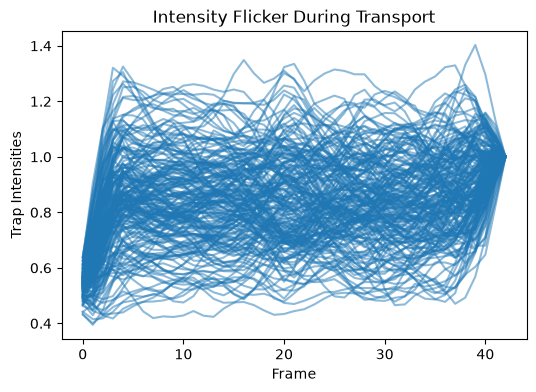

In [312]:
plt.figure(figsize=(6, 4))
for n in range(phi_foc_array_lpi.shape[1]):
    plt.plot(np.arange(I_foc_array_lpi.shape[0]-1), I_foc_array_lpi[1:, n]/np.mean(I_foc_array_lpi[-1, :]), alpha=0.5, color='C0')
                
plt.xlabel("Frame")
plt.ylabel("Trap Intensities")
plt.title(f"Intensity Flicker During Transport")
plt.show()

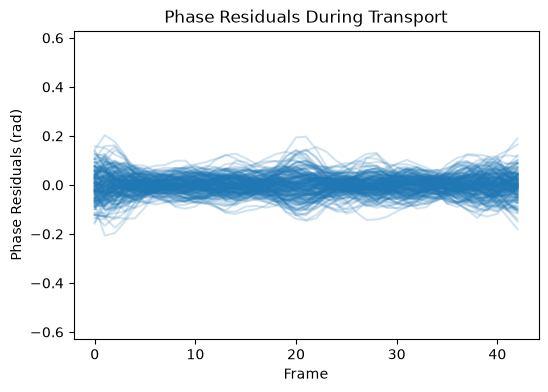

Standard deviation of phase residuals (LPI): 0.0413 rad


In [343]:
from scipy.optimize import curve_fit

plt.figure(figsize=(6, 4))
residuals_list = []

lin_fit = lambda x, m, b: m * x + b
for n in range(phi_foc_array_lpi.shape[1]):
    x = np.arange(phi_foc_array_lpi.shape[0]-1)
    y = np.unwrap(phi_foc_array_lpi[1:, n])
    popt, pcov = curve_fit(lin_fit, x, y)
    y_fit = lin_fit(x, *popt)
    residuals = y - y_fit
    #plt.plot(x, y, alpha=0.5, color='C0')
    #plt.plot(x, y_fit, alpha=0.8, color='C1')
    plt.plot(x, residuals, alpha=0.2, color='C0')
    residuals_list.append(residuals)

plt.ylim(-np.pi/5, np.pi/5)
plt.xlabel("Frame")
plt.ylabel("Phase Residuals (rad)")
plt.title(f"Phase Residuals During Transport")
plt.show()

residuals_array = np.array(residuals_list).flatten()
std_residuals = np.std(residuals_array)
print(f"Standard deviation of phase residuals (LPI): {std_residuals:.4f} rad")

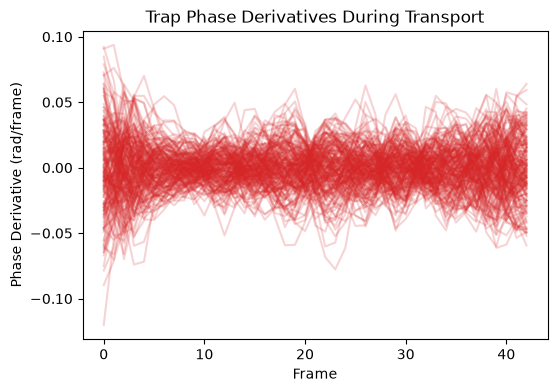

Standard deviation of phase standard deviations (LPI): 0.0173 rad/frame


In [350]:
from scipy.optimize import curve_fit

plt.figure(figsize=(6, 4))
phase_std_derivatives_list = []

lin_fit = lambda x, m, b: m * x + b
for n in range(phi_foc_array_lpi.shape[1]):
    x = np.arange(phi_foc_array_lpi.shape[0]-1)
    y = np.unwrap(phi_foc_array_lpi[1:, n])

    # Take the derivative of y
    y_derivative = np.gradient(y)
    std_derivative = np.std(y_derivative)
    plt.plot(x, y_derivative - np.mean(y_derivative), alpha=0.2, color='C3')
    phase_std_derivatives_list.append(std_derivative)

plt.xlabel("Frame")
plt.ylabel("Phase Derivative (rad/frame)")
plt.title(f"Trap Phase Derivatives During Transport")
plt.show()

phase_std_derivatives_array = np.array(phase_std_derivatives_list).flatten()
std_phase_std_derivatives = np.mean(phase_std_derivatives_array)
print(f"Standard deviation of phase standard deviations (LPI): {std_phase_std_derivatives:.4f} rad/frame")

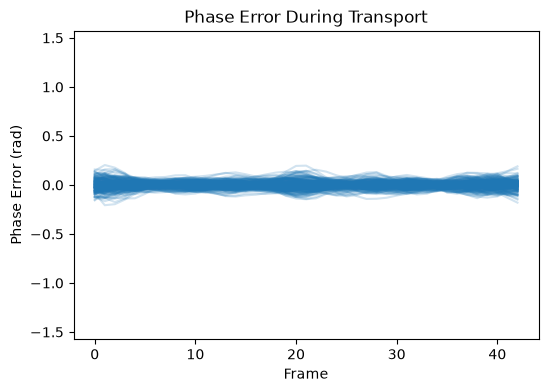

Standard deviation of phase residuals (LPI): 0.0413 rad


In [351]:
from scipy.optimize import curve_fit

plt.figure(figsize=(6, 4))
residuals_list = []

lin_fit = lambda x, m, b: m * x + b
for n in range(phi_foc_array_lpi.shape[1]):
    x = np.arange(phi_foc_array_lpi.shape[0]-1)
    y = np.unwrap(phi_foc_array_lpi[1:, n])
    popt, pcov = curve_fit(lin_fit, x, y)
    y_fit = lin_fit(x, *popt)
    residuals = y - y_fit
    #plt.plot(x, y, alpha=0.5, color='C0')
    #plt.plot(x, y_fit, alpha=0.8, color='C1')
    plt.plot(x, residuals, alpha=0.2, color='C0')
    residuals_list.append(residuals)

plt.ylim(-np.pi/2, np.pi/2)
plt.xlabel("Frame")
plt.ylabel("Phase Error (rad)")
plt.title(f"Phase Error During Transport")
plt.show()

residuals_array = np.array(residuals_list).flatten()
std_residuals = np.std(residuals_array)
print(f"Standard deviation of phase residuals (LPI): {std_residuals:.4f} rad")

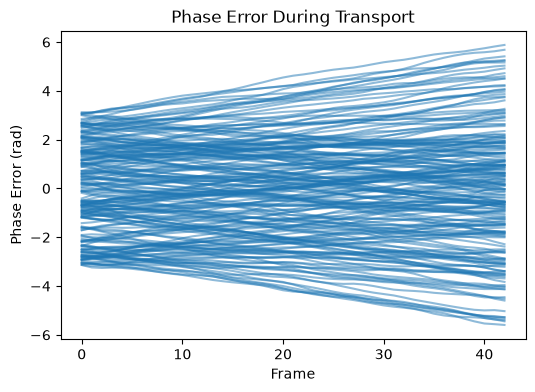

Standard deviation of phase residuals (LPI): 0.0413 rad


In [330]:
from scipy.optimize import curve_fit

plt.figure(figsize=(6, 4))
residuals_list = []

lin_fit = lambda x, m, b: m * x + b
for n in range(phi_foc_array_lpi.shape[1]):
    x = np.arange(phi_foc_array_lpi.shape[0]-1)
    y = np.unwrap(phi_foc_array_lpi[1:, n])
    popt, pcov = curve_fit(lin_fit, x, y)
    y_fit = lin_fit(x, *popt)
    residuals = y - y_fit
    plt.plot(x, y, alpha=0.5, color='C0')
    #plt.plot(x, y_fit, alpha=0.8, color='C1')
    #plt.plot(x, residuals, alpha=0.2, color='C0')
    residuals_list.append(residuals)

#plt.ylim(-np.pi/2, np.pi/2)
plt.xlabel("Frame")
plt.ylabel("Phase Error (rad)")
plt.title(f"Phase Error During Transport")
plt.show()

residuals_array = np.array(residuals_list).flatten()
std_residuals = np.std(residuals_array)
print(f"Standard deviation of phase residuals (LPI): {std_residuals:.4f} rad")

In [353]:
import os
import pickle
import time

data_dir = "C:\\Users\\tweez\\Box\\Working folder\\caftweezers\\Data\\13Aug26"
dataset_dir = os.path.join(data_dir, "rearrangement_phase_flicker")

# Create the dataset directory if it doesn't exist
os.makedirs(dataset_dir, exist_ok=True)

# Save x_on_array, y_on_array, I_foc_array_lpi, phi_foc_array_lpi, residuals_array to a pickle file
with open(os.path.join(dataset_dir, "phase_flicker_data.pkl"), "wb") as f:
    pickle.dump({
        "x_on_array": x_on_array,
        "y_on_array": y_on_array,
        "I_foc_array_lpi": I_foc_array_lpi,
        "phi_foc_array_lpi": phi_foc_array_lpi,
        "residuals_array": residuals_array,
        "phase_std_derivatives_array": phase_std_derivatives_array
    }, f)

# Save contextual information about the experiment to a text file
with open(os.path.join(dataset_dir, "experiment_info.txt"), "w") as f:
    f.write(f"Dataset Title: rearrangement_phase_flicker\n")
    f.write(f"Date: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"""
    Phase flicker analysis during rearrangement from 20x20 to 14x14 array.
    Maximum step size (d0) = 0.5, profile = linear.
    Standard deviation of phase residuals (LPI): {std_residuals:.4f} rad
    """)

---

## Rearrangement Exp 3

In [82]:
def extract_survival_probability(imgs1, imgs2, grid_positions, grid_shape, threshold=40, window_size=5):
    pr_1, eta_1, thresh_1, fidelity_1 = an.get_array_loading_statistics(imgs1, grid_positions, grid_shape, threshold_detection=False, threshold=threshold, window_size=window_size, binning=60, show_histogram=False, verbose=False)
    pr_2, eta_2, thresh_2, fidelity_2 = an.get_array_loading_statistics(imgs2, grid_positions, grid_shape, threshold_detection=False, threshold=threshold, window_size=window_size, binning=60, show_histogram=False, verbose=False)
    survival_fractions = []
    for i in range(pr_1.shape[0]):

        pr_mat_1 = pr_1[i]
        pr_mat_2 = pr_2[i]

        pr_mat_1_binary = (pr_mat_1 > thresh_1).astype(int)
        pr_mat_2_binary = (pr_mat_2 > thresh_2).astype(int)
        survival_matrix = pr_mat_1_binary * pr_mat_2_binary

        init_occupation = pr_mat_1_binary.sum()
        final_occupation = pr_mat_2_binary.sum()
        survival_count = survival_matrix.sum()
        survival_fraction = survival_count / init_occupation if init_occupation > 0 else 0
        survival_fractions.append(survival_fraction)

    survival_probability = np.mean(survival_fractions)
    return survival_probability

In [83]:
coordinator = Rearrangement({"camera": hamcam, "slm": slm, "phasemask_generator": PM}, {})

data1, array_shape1 = np.stack(terms1[:4]), terms1[4]
data2, array_shape2 = np.stack(terms2[:4]), terms2[4]
await asyncio.to_thread(
    coordinator.initialise,
    data1, data2, array_shape1, array_shape2,
    d0=0.5, fps=1/(1e-6), threshold=an.convert_photons_to_counts(threshold_1)*1.1,
    grid_positions=grid_positions_1, profile="linear", window_size=5, feature_size=10, 
    detector=scorer, num_images=2
)

Occupancy via PSF detector (window 9, threshold 2.8).
Rearrangement node initialised.


In [84]:
# Experiment and camera setup
n_iterations = 1
exp.set_motmaster_experiment("RbTweezerBasic2026_2_Assemble")
exp.set_iterations(n_iterations)
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)

{'ok': True,
 'command': 'interface_method',
 'method': 'set_run_until_stopped',
 'state': 'accepted'}

In [85]:
modvcflist = np.linspace(-10.0, 10.0, 20)

N_iterations = 20 
tot_imgs_list = []
for it, modvcf in enumerate(modvcflist):
    imgs_list = []

    counter = 0
    while counter < N_iterations:
        print(f"Datapoint {it+1}: Running experiment iteration {counter+1} / {N_iterations}")
        rearrangement_task = asyncio.create_task(asyncio.to_thread(coordinator.arm_rearrangement))
        time.sleep(0.1)
        exp.start_motmaster_experiment({
                    "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
                    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
                    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
                    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
                    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
                    "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
                    "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
                    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
                    "BackgroundDrop": 0, "TweezerModulation":1, "tTweezerSetVVA0": 8.0, "tTweezerSetVVA1": 10.0, "tTweezerModulationVCF": modvcf})
        img0, imgs1, timings = await rearrangement_task
        print("Images acquired from rearrangement node.")
        if imgs1.sum() == 0:
            print(f"Empty image received at iteration {counter+1}. Repeating...")
        else:
            imgs_list.append([img0, *imgs1])
            counter += 1

    tot_imgs_list.append(imgs_list)
tot_imgs_array = np.array(tot_imgs_list)

Datapoint 1: Running experiment iteration 1 / 20
Rearrangement complete: 26 frames, 22.1119ms total (occupancy 0.1658ms, calculation+upload 21.9461ms).
Images acquired from rearrangement node.
Datapoint 1: Running experiment iteration 2 / 20
Rearrangement complete: 22 frames, 19.6100ms total (occupancy 0.1635ms, calculation+upload 19.4465ms).
Images acquired from rearrangement node.
Datapoint 1: Running experiment iteration 3 / 20
Rearrangement complete: 22 frames, 18.9727ms total (occupancy 0.1289ms, calculation+upload 18.8438ms).
Images acquired from rearrangement node.
Datapoint 1: Running experiment iteration 4 / 20
Rearrangement complete: 16 frames, 15.1795ms total (occupancy 0.1263ms, calculation+upload 15.0532ms).
Images acquired from rearrangement node.
Datapoint 1: Running experiment iteration 5 / 20
Rearrangement complete: 26 frames, 21.9556ms total (occupancy 0.1923ms, calculation+upload 21.7633ms).
Images acquired from rearrangement node.
Datapoint 1: Running experiment ite

Modulation VCF: -10.00, Survival Probability: 0.9623
Modulation VCF: -8.95, Survival Probability: 0.9558
Modulation VCF: -7.89, Survival Probability: 0.9253
Modulation VCF: -6.84, Survival Probability: 0.8862
Modulation VCF: -5.79, Survival Probability: 0.9091
Modulation VCF: -4.74, Survival Probability: 0.9447
Modulation VCF: -3.68, Survival Probability: 0.9121
Modulation VCF: -2.63, Survival Probability: 0.8205
Modulation VCF: -1.58, Survival Probability: 0.6181
Modulation VCF: -0.53, Survival Probability: 0.4415
Modulation VCF: 0.53, Survival Probability: 0.5716
Modulation VCF: 1.58, Survival Probability: 0.6757
Modulation VCF: 2.63, Survival Probability: 0.8399
Modulation VCF: 3.68, Survival Probability: 0.9011
Modulation VCF: 4.74, Survival Probability: 0.9150
Modulation VCF: 5.79, Survival Probability: 0.9322
Modulation VCF: 6.84, Survival Probability: 0.9268
Modulation VCF: 7.89, Survival Probability: 0.9350
Modulation VCF: 8.95, Survival Probability: 0.8935
Modulation VCF: 10.0

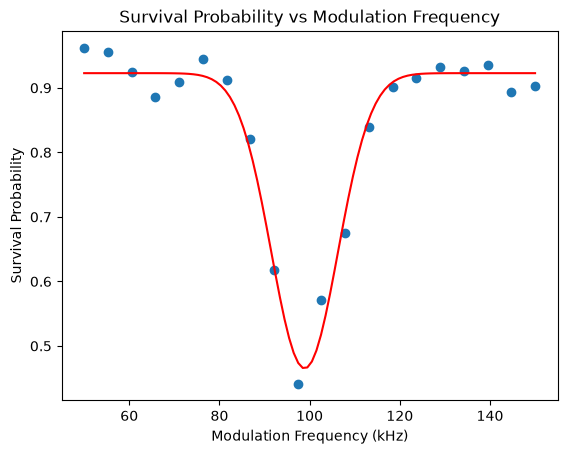

In [94]:
from scipy.optimize import curve_fit

survival_prob_list = []
for it, modvcf in enumerate(modvcflist):
    imgs1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in tot_imgs_array[it, :, 1, :, :]]
    imgs2 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in tot_imgs_array[it, :, 2, :, :]]
    survival_prob = extract_survival_probability(imgs1, imgs2, grid_positions_2, [7,7], threshold=40, window_size=5)
    survival_prob_list.append(survival_prob)
    print(f"Modulation VCF: {modvcf:.2f}, Survival Probability: {survival_prob:.4f}")

modflist = np.linspace(50, 150, len(modvcflist))

# Fit a double dip Gaussian function to the survival probability data
def dip_gaussian(x, a1, mu1, sigma1, c):
    return c - a1 * np.exp(-((x - mu1) ** 2) / (2 * sigma1 ** 2))

popt, pcov = curve_fit(dip_gaussian, modflist[2:-2], survival_prob_list[2:-2], p0=[0.5, 100, 5, 0.95])

x_fit = np.linspace(min(modflist), max(modflist), 100)
y_fit = dip_gaussian(x_fit, *popt)

plt.scatter(modflist, survival_prob_list)
plt.plot(x_fit, y_fit, 'r-', label='Fit')
plt.xlabel("Modulation Frequency (kHz)")
plt.ylabel("Survival Probability")
plt.title("Survival Probability vs Modulation Frequency")
print(f"Trap Frequency = {popt[1]/2:.4f} kHz")

---

Looking for trap sites...
7x7 array detected.


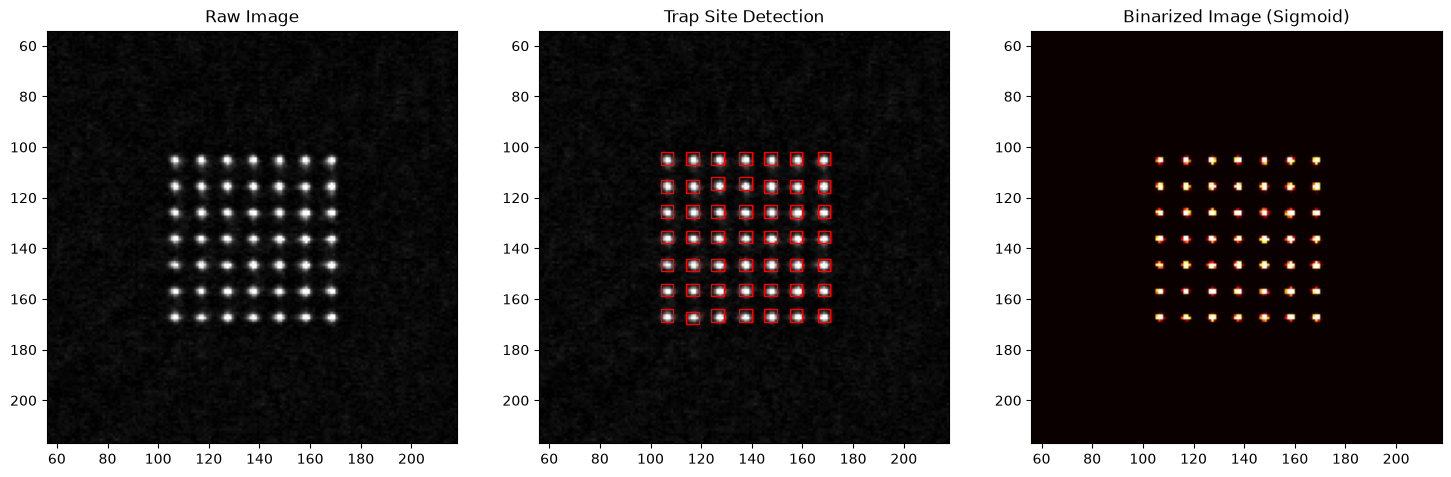

Trap (0, 0) Loading Probability : 91.67 %
Trap (0, 1) Loading Probability : 93.75 %
Trap (0, 2) Loading Probability : 93.75 %
Trap (0, 3) Loading Probability : 93.75 %
Trap (0, 4) Loading Probability : 96.88 %
Trap (0, 5) Loading Probability : 94.79 %
Trap (0, 6) Loading Probability : 98.96 %
Trap (1, 0) Loading Probability : 93.75 %
Trap (1, 1) Loading Probability : 94.79 %
Trap (1, 2) Loading Probability : 97.92 %
Trap (1, 3) Loading Probability : 97.92 %
Trap (1, 4) Loading Probability : 98.96 %
Trap (1, 5) Loading Probability : 95.83 %
Trap (1, 6) Loading Probability : 93.75 %
Trap (2, 0) Loading Probability : 96.88 %
Trap (2, 1) Loading Probability : 91.67 %
Trap (2, 2) Loading Probability : 89.58 %
Trap (2, 3) Loading Probability : 94.79 %
Trap (2, 4) Loading Probability : 96.88 %
Trap (2, 5) Loading Probability : 98.96 %
Trap (2, 6) Loading Probability : 96.88 %
Trap (3, 0) Loading Probability : 93.75 %
Trap (3, 1) Loading Probability : 96.88 %
Trap (3, 2) Loading Probability : 

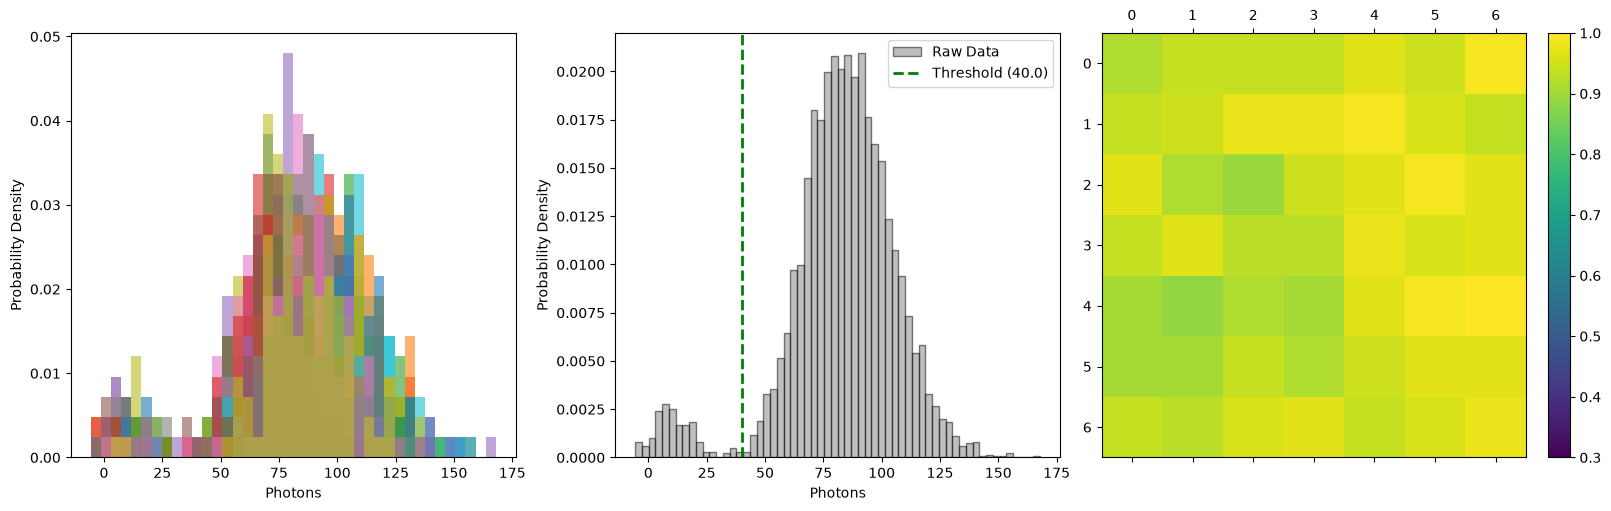

In [ ]:
n = 2
imgs_n = tot_imgs[:, n, :, :]
imgs__n_mean = imgs_n.mean(axis=0)
imgs_n_mean_filtered = an.morphological_tophat_high_pass(imgs__n_mean, feature_size=feature_size)
array_shape_n = [7, 7]

window, feature_size = 5, 10
grid_positions_1, detection_threshold = an.detect_trap_sites(imgs_n_mean_filtered, array_shape_n, detection_step=100)
an.visualize_results(imgs_n_mean_filtered, grid_positions_1, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)

imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs_n]
photon_rates, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions_1, array_shape_n, threshold_detection=False, threshold=40, window_size=window, binning=60)

Looking for trap sites...
7x7 array detected.


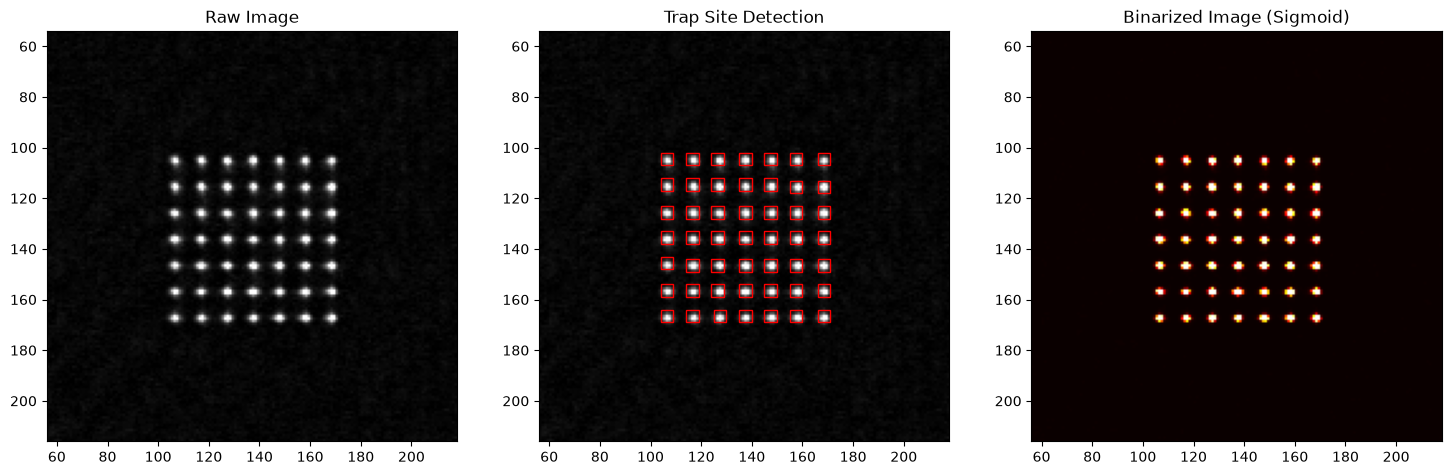

Trap (0, 0) Loading Probability : 95.74 %
Trap (0, 1) Loading Probability : 95.21 %
Trap (0, 2) Loading Probability : 94.15 %
Trap (0, 3) Loading Probability : 96.81 %
Trap (0, 4) Loading Probability : 94.68 %
Trap (0, 5) Loading Probability : 97.87 %
Trap (0, 6) Loading Probability : 91.49 %
Trap (1, 0) Loading Probability : 95.74 %
Trap (1, 1) Loading Probability : 95.21 %
Trap (1, 2) Loading Probability : 96.81 %
Trap (1, 3) Loading Probability : 93.09 %
Trap (1, 4) Loading Probability : 96.81 %
Trap (1, 5) Loading Probability : 97.87 %
Trap (1, 6) Loading Probability : 96.81 %
Trap (2, 0) Loading Probability : 92.55 %
Trap (2, 1) Loading Probability : 94.15 %
Trap (2, 2) Loading Probability : 94.68 %
Trap (2, 3) Loading Probability : 94.15 %
Trap (2, 4) Loading Probability : 94.68 %
Trap (2, 5) Loading Probability : 96.28 %
Trap (2, 6) Loading Probability : 96.81 %
Trap (3, 0) Loading Probability : 95.74 %
Trap (3, 1) Loading Probability : 95.74 %
Trap (3, 2) Loading Probability : 

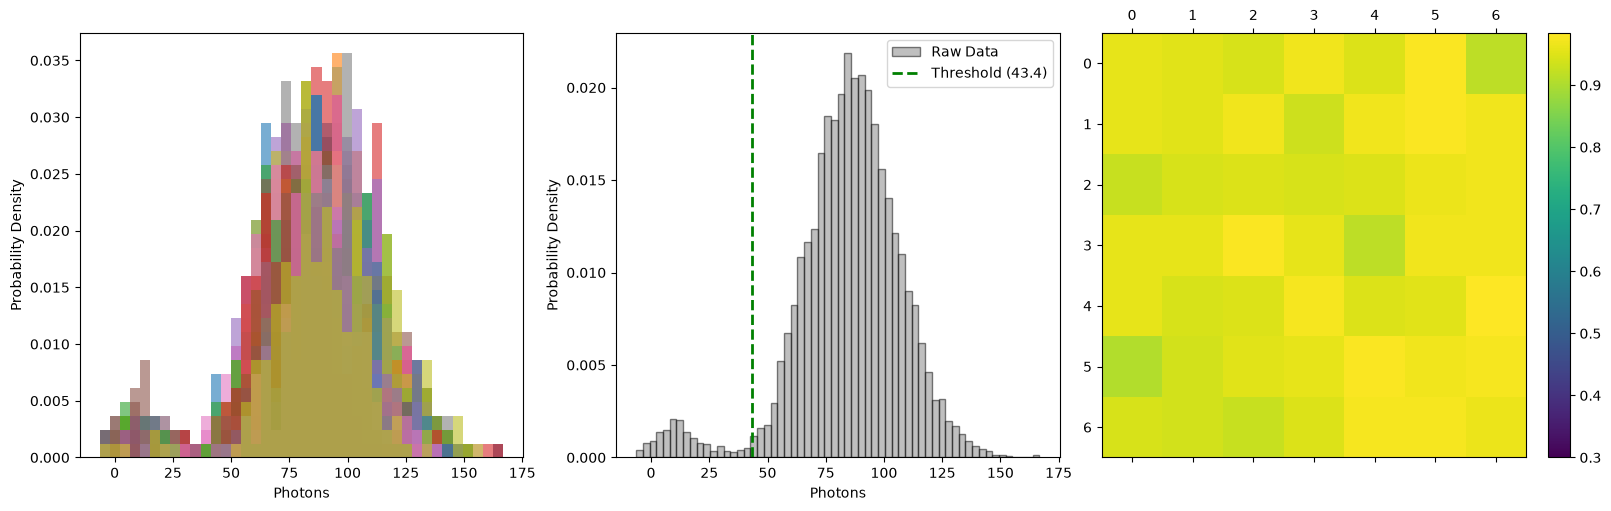

In [ ]:
array_shape_2 = [7, 7]
window = 5
feature_size = 10

grid_positions_2, detection_threshold = an.detect_trap_sites(imgs1_mean_filtered, array_shape_2, detection_step=200)
an.visualize_results(imgs1_mean_filtered, grid_positions_2, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)

imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
photon_rates, loading_probabilities, _, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions_2, array_shape_2, threshold_detection=False, threshold=threshold_1, window_size=window, binning=60)

In [ ]:
loading_probabilities.mean() / baseline_survival_probability

np.float64(0.9901739759523527)

In [95]:
hamcam.close()
slm.close()
motcam.close()

ImagEM X2 camera closed.
SLM 1 closed.
Thorlabs TLCamera - motcam - closed.
